# Using trials_data, plot graphs to look at (mainly) statistical errors in approximation and actual

## Imports

In [1]:
import csv
import matplotlib.pyplot as plt
import pandas as pd
from math import log, e, sqrt, pi
from statistics import NormalDist
import pickle
from scipy.stats import f_oneway, norm
import numpy as np

## Constants

In [2]:
N = 2 ** 16
p = 1 - e**(-2) # our table coverage
t = round(log(1-p)/log(1-N**(-1/3)))
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
################################################################################################
# get number of cherry picks per column from simulation data
optimisation_kis = []
with open("cherry_N_16_different_alpha_0.5_0.95_optimisation_results.pkl", "rb") as f:
    data = pickle.load(f)

for item in data:
    optimisation_kis.append(item[0])

## Helper Functions

### Calculate m_0

In [3]:
def calc_m0(N, t, alpha):
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    return round(mt_target/(1-alpha))    # our starting m_0

### Approximation

In [4]:
# given N, K (list of number of RF trials per column), and starting m_0, approximate the m_i values for each column
def approximate_columns(N, K, m_0):
    m = m_0  # starting m value

    m_values = []  # store m values for each iteration
    m_values.append(m_0)

    # for the number of columns
    for k in K:
        # Calculate E1 and E2
        E1 = (1 - 1 / N) ** m
        E2 = (1 - 2 / N) ** m

        # calculate the statistical average of m_i
        average = N * (1 - E1)

        # find variance, and thus standard deviation
        if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:   # this equation gives the variance, so sqrt to get standard deviation
            # if it is negative (error), set it to 0
            sd = 0
        else:
            # count the statistical variance of m_i+1 otherwise
            sd = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))

        # expectance of maximum of K samples 
        m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
        m_values.append(m)

    return m_values

In [5]:
def approximate_columns_m(K, m_0):
    m = m_0  # starting m value

    m_values = []  # store m values for each iteration
    m_values.append(m_0)

    # for the number of columns
    for k in K:
        # Calculate E1 and E2
        E1 = (1 - 1 / m) ** m
        E2 = (1 - 2 / m) ** m

        # calculate the statistical average of m_i
        average = m * (1 - E1)

        # find variance, and thus standard deviation
        if m * ((m - 1) * E2 + E1 - m * E1 ** 2) < 0:   # this equation gives the variance, so sqrt to get standard deviation
            # if it is negative (error), set it to 0
            sd = 0
        else:
            # count the statistical variance of m_i+1 otherwise
            sd = sqrt(m * ((m - 1) * E2 + E1 - m * E1 ** 2))

        # expectance of maximum of K samples 
        m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
        m_values.append(m)

    return m_values

In [6]:
# get mean
def get_mean_variance(m):
    # Calculate E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m

    # calculate the statistical average of m_i
    average = N * (1 - E1)

    # find variance, and thus standard deviation
    if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:   # this equation gives the variance, so sqrt to get standard deviation
        # if it is negative (error), set it to 0
        var = 0
    else:
        # count the statistical variance of m_i+1 otherwise
        var = N * ((N - 1) * E2 + E1 - N * E1 ** 2)

    return average, var

In [7]:
def get_approximate_mi(average, k, sd):
    return average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd

## Look at how approximation is affected by cherry-picking over all columns for a specific config

For one config:
- use ...points.csv file
- Plot each column as a box plot 
- plot approximation formula


### for alpha = 0.5

In [8]:
%%script false

# import the points csv file
points_all_df = pd.read_csv("trials_data/cherry_N_16_20_trials_alpha_0.5_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])

# get the approximated m values 
approximated_m_values = approximate_columns(N, optimisation_kis[0], calc_m0(N, t, alphas[0]))

# plot the approximation results against the simulation results
plt.figure(figsize=(10, 6))
plt.plot(approximated_m_values, label="Approximated m values")

# plot each column as a box plot - but start at 0 not 1
plt.boxplot(points_df.values, positions=range(len(points_df.columns)), widths=0.6)

plt.xlabel("K (Number of cherry-picks per column)")
plt.ylabel("Number of unique endpoints")
# only show every 5 x-ticks
plt.xticks(ticks=range(0, len(optimisation_kis[0])+1, 5), labels=range(0, len(optimisation_kis[0])+1, 5))

plt.title(f"Approximation vs Actual MT for N=$2^{{16}}$ and $\\alpha$={alphas[0]}")
plt.grid(True)
plt.legend()    
plt.show()

Couldn't find program: 'false'


### For all alpha

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


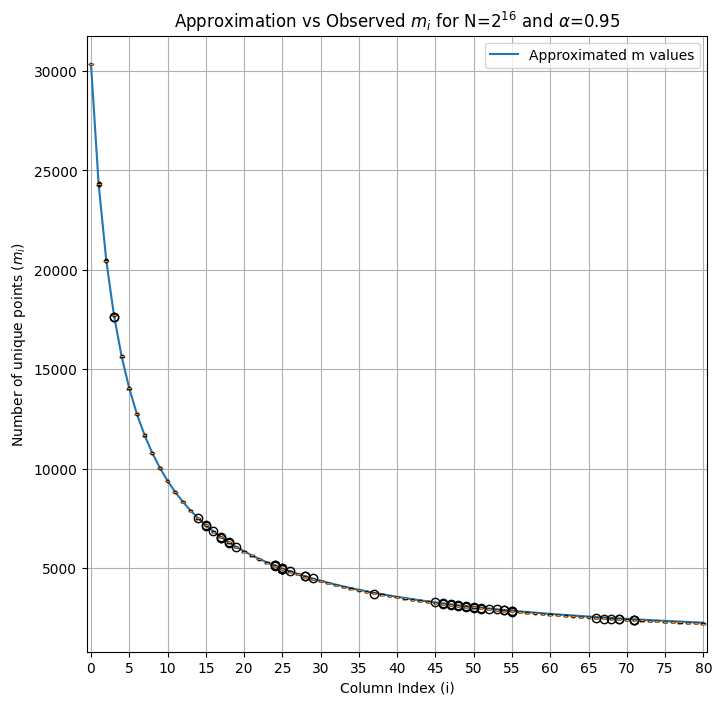

In [ ]:
## plot just alpha = 0.95
approximated_m_values = approximate_columns(N, optimisation_kis[9], calc_m0(N, t, alphas[9]))
plt.figure(figsize=(8, 8))
plt.plot(approximated_m_values, label="Approximated m values")
# plot each column as a box plot - but start at 0 not 1
points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_0.95_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])
plt.boxplot(points_df.values, positions=range(len(points_df.columns)), widths=0.5)
plt.xlabel("Column Index (i)")
plt.ylabel(r"Number of unique points ($m_i$)")
plt.title(f"Approximation vs Observed $m_i$ for N=$2^{{16}}$ and $\\alpha$={alphas[9]}")
# only show every 10 x-ticks
plt.xticks(ticks=range(0, len(optimisation_kis[9])+1, 5), labels=range(0, len(optimisation_kis[9])+1, 5))
plt.grid(True)
plt.legend() 
# save as eps and pdf
# plt.savefig(f"cherry_N_16_alpha_0.95_approximation_vs_actual.eps", format="eps")
# plt.savefig(f"cherry_N_16_alpha_0.95_approximation_vs_actual.pdf", format="pdf")   
plt.show()

In [22]:
## plot on cop model
#Imports
import os

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from math import sqrt, pi, log
from statistics import NormalDist

# need to import k values from the optimisation results
k_values = [] 
with open("cherry_N_16_different_alpha_0.5_0.95_optimisation_results.pkl", "rb") as f:
    data = pickle.load(f)

# print dimentions of data
print("Dimensions of data:", len(data[-1][0]))

kis = data[-1][0]
print(kis[-1])


#Functions 

def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def dp_matrix(N, m):

    """
    Returns an array of probabilites for each index number of bins to be occupied by m balls
    """

    # only store one array instead of a matrix, since we only need the previous row to calculate the current row
    prev = np.zeros(N + 1, dtype=np.float64)
    prev[0] = 1.0

    for i in range(1, m + 1):
        # next row
        curr = np.zeros(N + 1, dtype=np.float64)
        # for all bins
        j = np.arange(min(i, N) + 1)

        # if ball lands in a new bin (j > 0)
        # create an array of which elements of j are above 0
        # divide by N to get probabilities
        mask_new = j > 0
        curr[j[mask_new]] += prev[j[mask_new] - 1] * (N - (j[mask_new] - 1)) / N

        # if ball lands in existing bin (j <= i - 1)
        # create an array of which elements of j are less than or equal to i - 1
        # divide by N to get probabilities
        mask_existing = j <= i - 1
        curr[j[mask_existing]] += prev[j[mask_existing]] * j[mask_existing] / N

        # set prev to curr for next iteration
        prev = curr

    return prev[:min(m, N) + 1]


def dp_occupancy(N, m, j):
    matrix = dp_matrix(N, m)
    return matrix[j] if j < len(matrix) else 0.0


def dp_calc_max(N, m, k):
    matrix = dp_matrix(N, m)

    # Calculate CDFs using cumulative sum
    cdfs = np.cumsum(matrix)
    
    # Raise to power k
    cdf_powers = cdfs**k
    
    # Sum (1 - cdf^k) for y=0 to m
    return np.sum(1 - cdf_powers)

def table_cop(N, t, alpha, k_values):
    m0 = round(calculate_m0(N, t, alpha))
    m_values = [m0]
    m = m0

    for i in range(t):
        m = round(dp_calc_max(N, m, k_values[i]))
        m_values.append(m)

    return m_values

m_values_cop = table_cop(N, t, 0.95, kis)


Dimensions of data: 80
3696.4004838048336


In [29]:
# store kis in pkl file
with open("k-vector.pkl", "wb") as f:
    pickle.dump(kis, f)

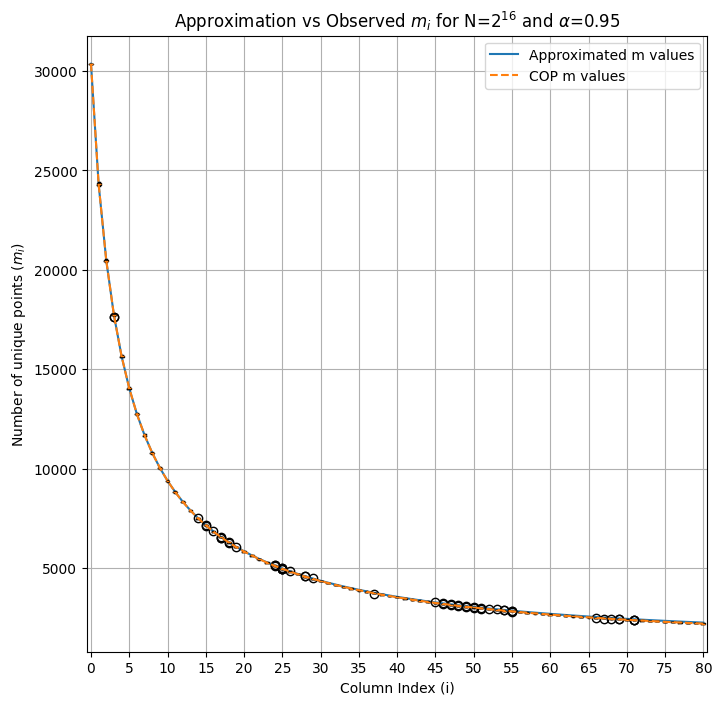

In [23]:
## plot just alpha = 0.95
approximated_m_values = approximate_columns(N, optimisation_kis[9], calc_m0(N, t, alphas[9]))
plt.figure(figsize=(8, 8))
plt.plot(approximated_m_values, label="Approximated m values")
# plot each column as a box plot - but start at 0 not 1
points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_0.95_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])
plt.boxplot(points_df.values, positions=range(len(points_df.columns)), widths=0.5)

# plot m_values_cop
plt.plot(m_values_cop, label="COP m values", linestyle="dashed")

plt.xlabel("Column Index (i)")
plt.ylabel(r"Number of unique points ($m_i$)")
plt.title(f"Approximation vs Observed $m_i$ for N=$2^{{16}}$ and $\\alpha$={alphas[9]}")
# only show every 10 x-ticks
plt.xticks(ticks=range(0, len(optimisation_kis[9])+1, 5), labels=range(0, len(optimisation_kis[9])+1, 5))
plt.grid(True)
plt.legend() 
# save as eps and pdf
# plt.savefig(f"cherry_N_16_alpha_0.95_approximation_vs_actual.eps", format="eps")
# plt.savefig(f"cherry_N_16_alpha_0.95_approximation_vs_actual.pdf", format="pdf")   
plt.show()

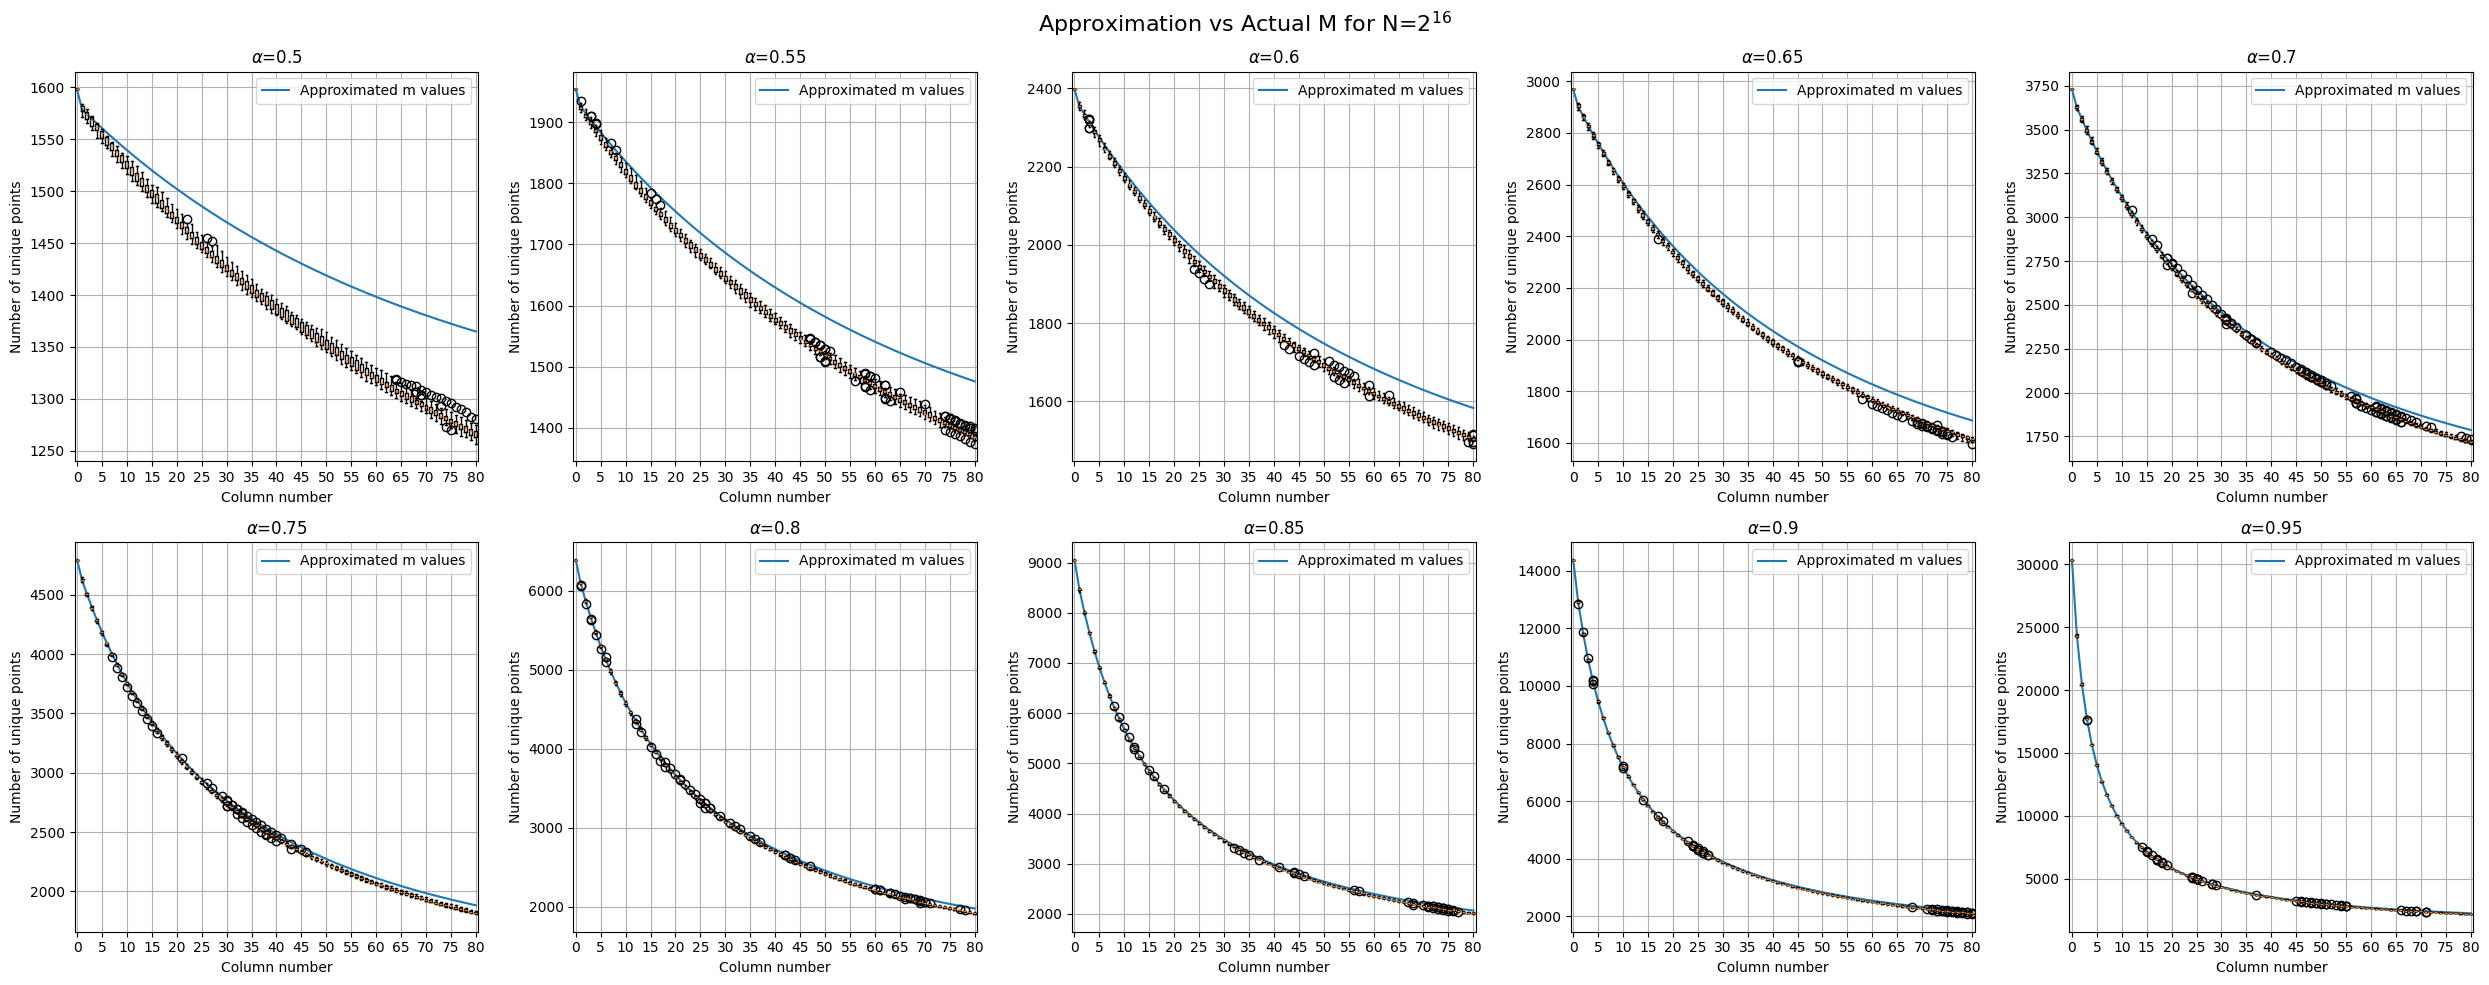

In [ ]:
%%script false

# plot these all on a 5 x 2 grid, keeping their axis and titles consistent
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=True, sharey=False)
axes = axes.flatten()  # Flatten to a 1D array for easy indexing

for i, alpha in enumerate(alphas):
    ax = axes[i]    

    # import the points csv file
    points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_{alpha}_points_per_column.csv")
    points_df = points_all_df.drop(columns=["Trial"])

    # get the approximated m values 
    approximated_m_values = approximate_columns(N, optimisation_kis[i], calc_m0(N, t, alpha))

    # plot the approximation results against the simulation results
    ax.plot(approximated_m_values, label="Approximated m values")

    # plot each column as a box plot - but start at 0 not 1
    ax.boxplot(points_df.values, positions=range(len(points_df.columns)), widths=0.6)

    ax.tick_params(labelbottom=True, labelleft=True) # Forces labels to show

    ax.set_xlabel("Column number")
    ax.set_ylabel("Number of unique points")
    # only show every 5 x-ticks
    ax.set_xticks(ticks=range(0, len(optimisation_kis[0])+1, 5))
    ax.set_xticklabels(labels=range(0, len(optimisation_kis[0])+1, 5))
    ax.set_title(f"$\\alpha$={alpha}")
    ax.grid(True)
    ax.legend()

plt.suptitle(f"Approximation vs Actual M for N=$2^{{16}}$", fontsize=16)
plt.tight_layout()
plt.show()

### Repeat for altered approximation

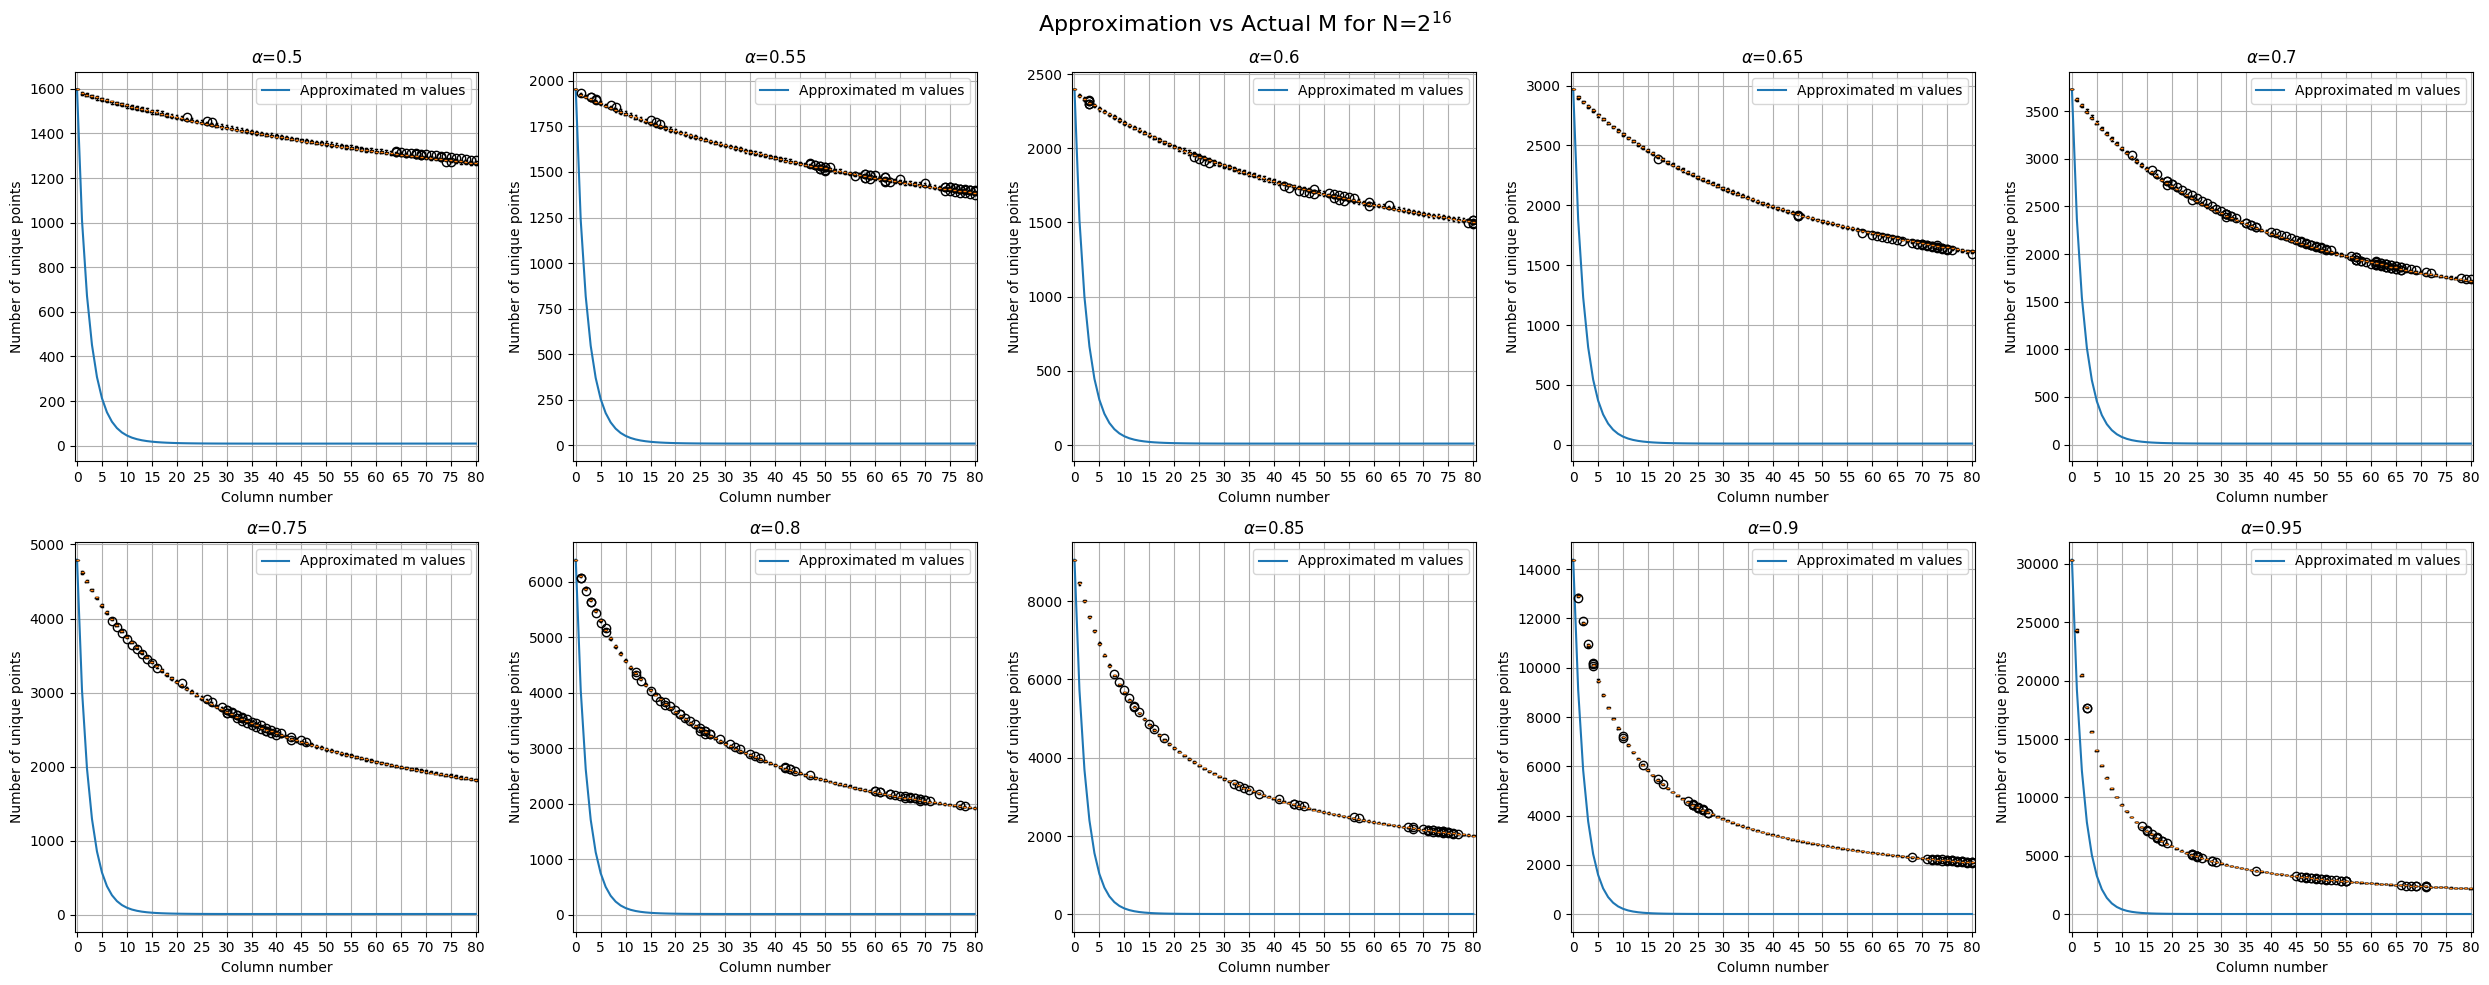

In [ ]:
%%script false

# plot these all on a 5 x 2 grid, keeping their axis and titles consistent
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=True, sharey=False)
axes = axes.flatten()  # Flatten to a 1D array for easy indexing

for i, alpha in enumerate(alphas):
    ax = axes[i]    

    # import the points csv file
    points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_{alpha}_points_per_column.csv")
    points_df = points_all_df.drop(columns=["Trial"])

    # get the approximated m values 
    approximated_m_values = approximate_columns_m(optimisation_kis[i], calc_m0(N, t, alpha))

    # plot the approximation results against the simulation results
    ax.plot(approximated_m_values, label="Approximated m values")

    # plot each column as a box plot - but start at 0 not 1
    ax.boxplot(points_df.values, positions=range(len(points_df.columns)), widths=0.6)

    ax.tick_params(labelbottom=True, labelleft=True) # Forces labels to show

    ax.set_xlabel("Column number")
    ax.set_ylabel("Number of unique points")
    # only show every 5 x-ticks
    ax.set_xticks(ticks=range(0, len(optimisation_kis[0])+1, 5))
    ax.set_xticklabels(labels=range(0, len(optimisation_kis[0])+1, 5))
    ax.set_title(f"$\\alpha$={alpha}")
    ax.grid(True)
    ax.legend()

plt.suptitle(f"Approximation vs Actual M for N=$2^{{16}}$", fontsize=16)
plt.tight_layout()
plt.show()

## Find rate of error as we move through K, and see if it matches what we see on our graphs

For each config 
- still using ...points.csv file
- plot percent error on each graph 

### For alpha = 0.5

In [12]:
%%script false

# import the points csv file
points_all_df = pd.read_csv("trials_data/cherry_N_16_20_trials_alpha_0.5_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])

# get the approximated m values 
approximated_m_values = approximate_columns(N, optimisation_kis[0], calc_m0(N, t, alphas[0]))

# Find the percent error of each sample compared to the approximation for each column and plot as a box plot
plt.figure(figsize=(10, 6))
percent_errors_df = (points_df - approximated_m_values).abs() / approximated_m_values * 100

plt.boxplot(percent_errors_df.values, positions=range(len(points_df.columns)), widths=0.6)

plt.xlabel("Column number")
plt.ylabel("Percent error (%)")
# only show every 5 x-ticks
plt.xticks(ticks=range(0, t+1, 5), labels=range(0, t+1, 5))

plt.title(f"Percent Error of Approximation vs Actual M for N=$2^{{16}}$ and $\\alpha$={alphas[0]}")
plt.grid(True)
plt.legend()    
plt.show()

Couldn't find program: 'false'


C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\896974149.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


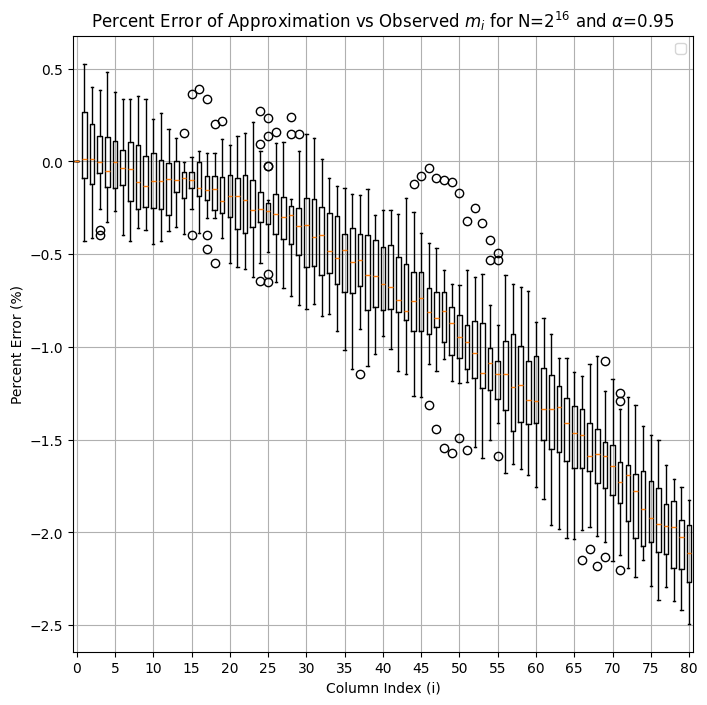

In [24]:
# for alpha = 0.95
points_all_df = pd.read_csv("trials_data/cherry_N_16_20_trials_alpha_0.95_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])

# get the approximated m values 
# approximated_m_values = approximate_columns(N, optimisation_kis[-1], calc_m0(N, t, alphas[-1]))

# Find the percent error of each sample compared to the approximation for each column and plot as a box plot
plt.figure(figsize=(8, 8))
# get the approximated m values 
approximated_m_values = approximate_columns(N, optimisation_kis[-1], calc_m0(N, t, 0.95))

# Find the percent error of each sample compared to the approximation for each column and plot as a box plot
# percent_errors_df = (points_df - approximated_m_values) / approximated_m_values * 100
percent_errors_df = (points_df - approximated_m_values) / approximated_m_values * 100
# Plot on the specific axis 'ax'
plt.boxplot(percent_errors_df.values, positions=range(len(points_df.columns)), widths=0.6)

plt.xlabel("Column Index (i)")
plt.ylabel("Percent Error (%)")
# only show every 5 x-ticks
plt.xticks(ticks=range(0, t+1, 5), labels=range(0, t+1, 5))

plt.title(f"Percent Error of Approximation vs Observed $m_i$ for N=$2^{{16}}$ and $\\alpha$={alphas[-1]}")
plt.grid(True)
plt.legend()    
# save as eps and pdf
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.eps", format="eps")
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.pdf", format="pdf")
plt.show()




The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


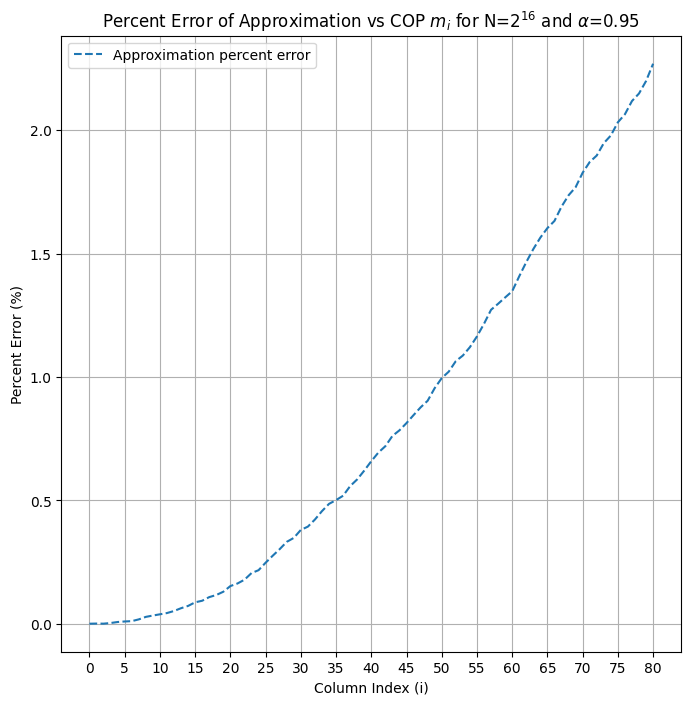

In [30]:
# for alpha = 0.95
points_all_df = pd.read_csv("trials_data/cherry_N_16_20_trials_alpha_0.95_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])

# get the approximated m values 
# approximated_m_values = approximate_columns(N, optimisation_kis[-1], calc_m0(N, t, alphas[-1]))

# Find the percent error of each sample compared to the approximation for each column and plot as a box plot
plt.figure(figsize=(8, 8))
# get the approximated m values 
approximated_m_values = approximate_columns(N, optimisation_kis[-1], calc_m0(N, t, 0.95))

# # Find the percent error of each sample compared to the approximation for each column and plot as a box plot
# # percent_errors_df = (points_df - approximated_m_values) / approximated_m_values * 100
# percent_errors_df = (points_df - approximated_m_values) / approximated_m_values * 100
# # Plot on the specific axis 'ax'
# plt.boxplot(percent_errors_df.values, positions=range(len(points_df.columns)), widths=0.6)

# plot on difference in cop model
percent_errors_cop = []
for i in range(len(m_values_cop)):
    percent_errors_cop.append((approximated_m_values[i] - m_values_cop[i]) / approximated_m_values[i] * 100)

plt.plot(percent_errors_cop, label="Approximation percent error", linestyle="dashed")

plt.xlabel("Column Index (i)")
plt.ylabel("Percent Error (%)")
# only show every 5 x-ticks
plt.xticks(ticks=range(0, t+1, 5), labels=range(0, t+1, 5))

plt.title(f"Percent Error of Approximation vs COP $m_i$ for N=$2^{{16}}$ and $\\alpha$={alphas[-1]}")
plt.grid(True)
plt.legend()    
# save as eps and pdf
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.eps", format="eps")
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.pdf", format="pdf")
plt.show()




C:\Users\psymf9\AppData\Local\Temp\ipykernel_1504\3177893782.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


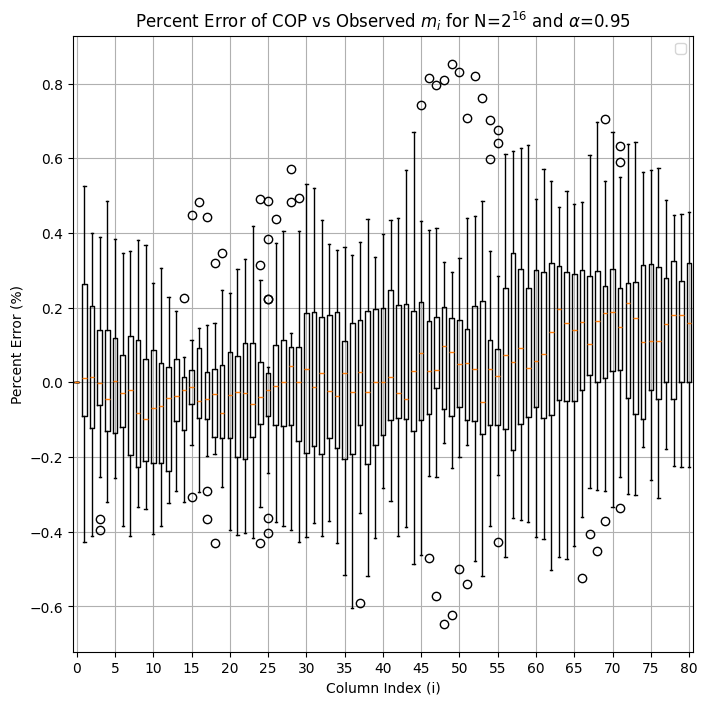

In [28]:
# for alpha = 0.95
points_all_df = pd.read_csv("trials_data/cherry_N_16_20_trials_alpha_0.95_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])

# get the approximated m values 
# approximated_m_values = approximate_columns(N, optimisation_kis[-1], calc_m0(N, t, alphas[-1]))

# Find the percent error of each sample compared to the approximation for each column and plot as a box plot
plt.figure(figsize=(8, 8))
# get the approximated m values 
approximated_m_values = approximate_columns(N, optimisation_kis[-1], calc_m0(N, t, 0.95))

# # Find the percent error of each sample compared to the approximation for each column and plot as a box plot
# percent_errors_df = (points_df - approximated_m_values) / approximated_m_values * 100
percent_errors_df = (points_df - m_values_cop) / m_values_cop * 100
# Plot on the specific axis 'ax'
plt.boxplot(percent_errors_df.values, positions=range(len(points_df.columns)), widths=0.6)

# # plot on difference in cop model
# percent_errors_cop = []
# for i in range(len(m_values_cop)):
#     percent_errors_cop.append((approximated_m_values[i] - m_values_cop[i]) / approximated_m_values[i] * 100)

# plt.plot(percent_errors_cop, label="COP percent error", linestyle="dashed")

plt.xlabel("Column Index (i)")
plt.ylabel("Percent Error (%)")
# only show every 5 x-ticks
plt.xticks(ticks=range(0, t+1, 5), labels=range(0, t+1, 5))

plt.title(f"Percent Error of COP vs Observed $m_i$ for N=$2^{{16}}$ and $\\alpha$={alphas[-1]}")
plt.grid(True)
plt.legend()    
# save as eps and pdf
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.eps", format="eps")
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.pdf", format="pdf")
plt.show()




C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\2957571327.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  percent_differences.append(mean_percent_errors[i] - mean_percent_errors[i-1])


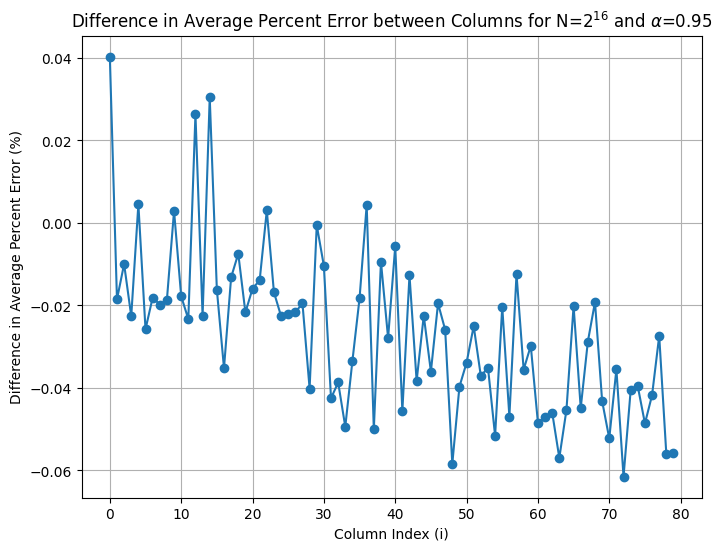

In [28]:
# plot difference in average percent error across columns
mean_percent_errors = percent_errors_df.mean()
percent_differences = []
for i in range(1, len(mean_percent_errors)):
    percent_differences.append(mean_percent_errors[i] - mean_percent_errors[i-1])

# plot percent differences
plt.figure(figsize=(8, 6))
plt.plot(percent_differences, marker='o')
plt.xlabel("Column Index (i)")
plt.ylabel("Difference in Average Percent Error (%)")
plt.title(f"Difference in Average Percent Error between Columns for N=$2^{{16}}$ and $\\alpha$={alphas[-1]}")
plt.grid(True)

### For all alphas

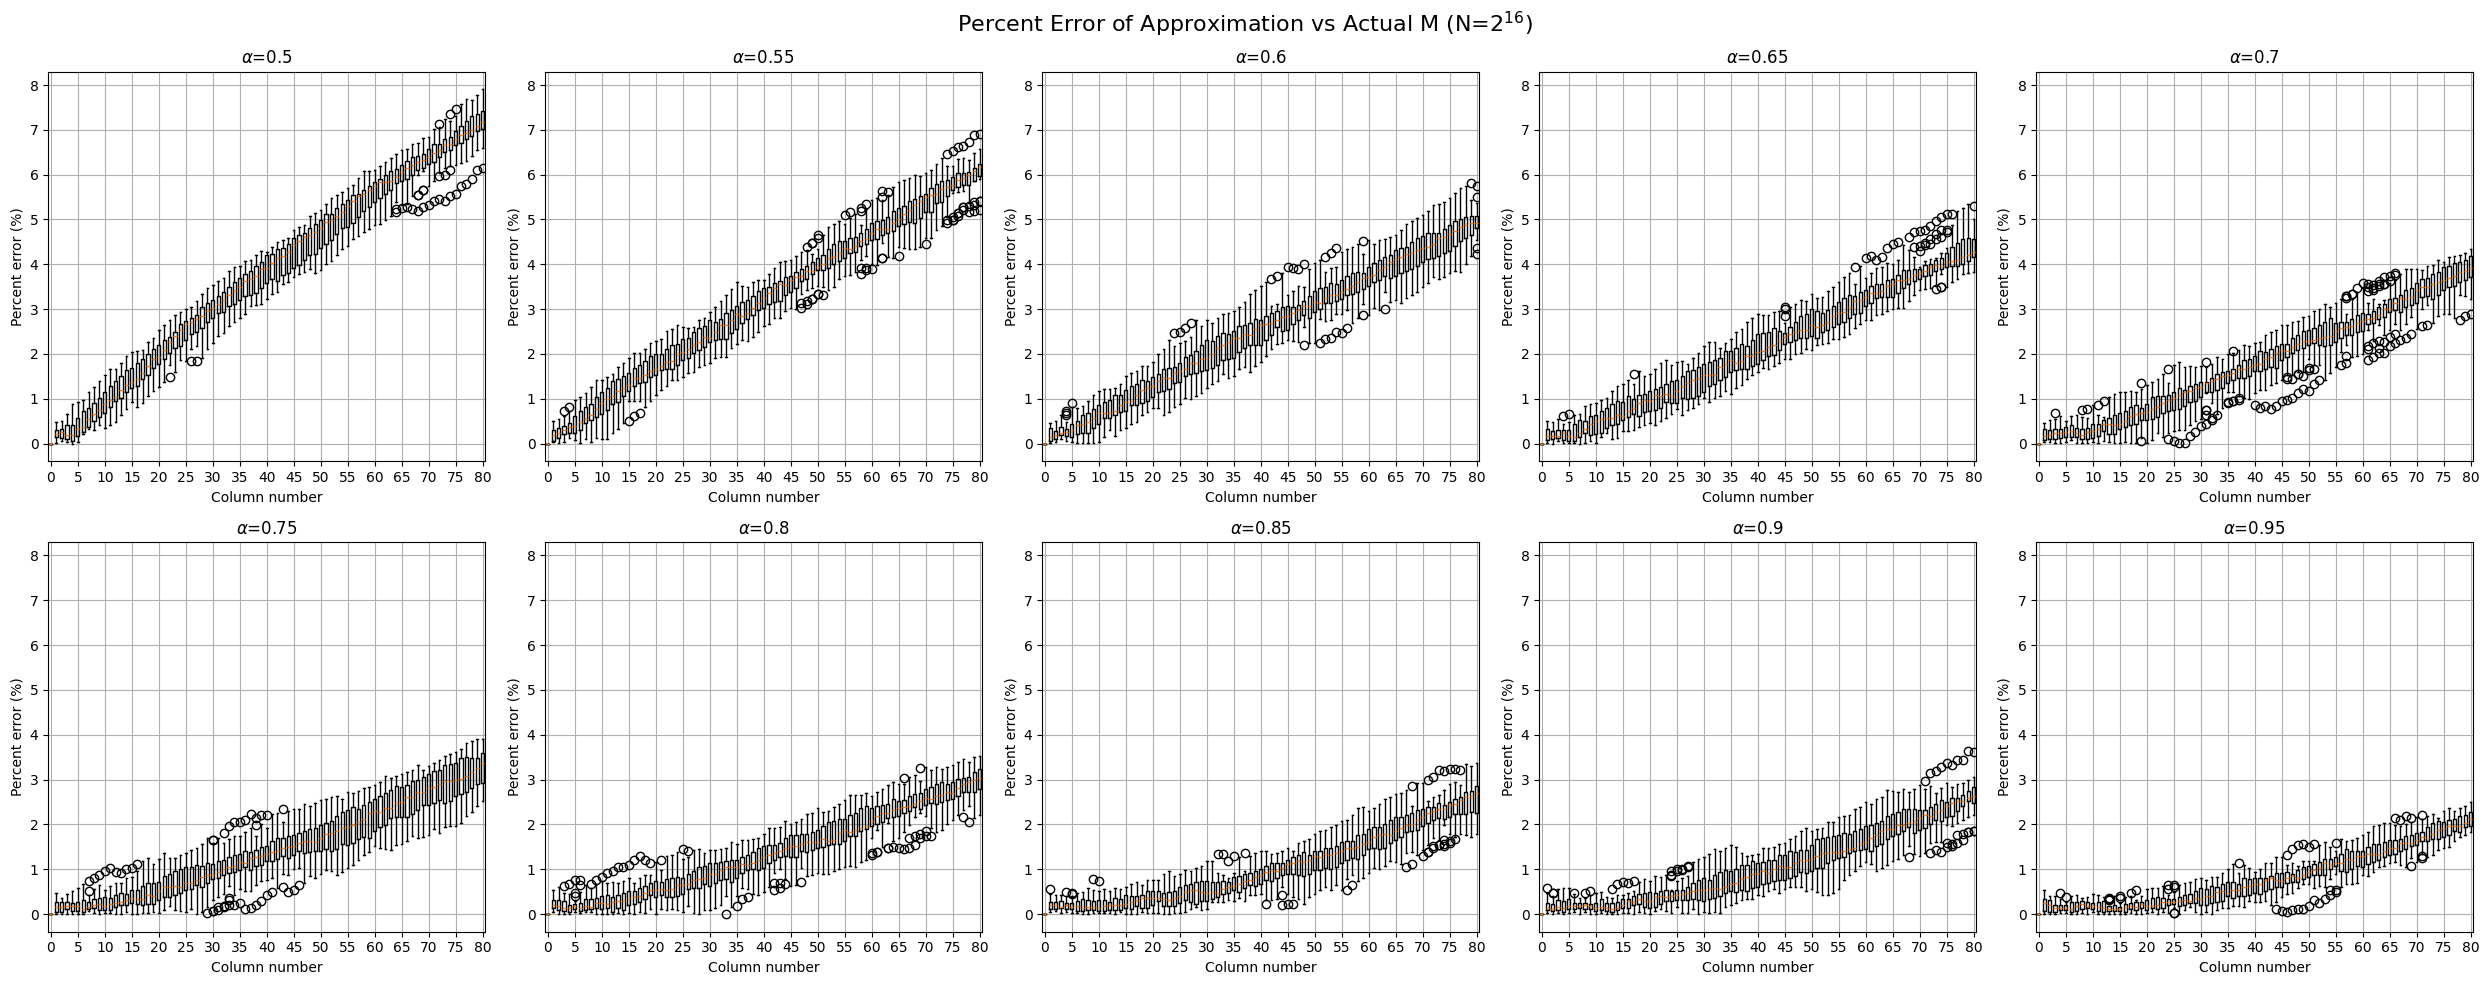

In [15]:
# plot these all on a 5 x 2 grid, keeping their axis and titles consistent
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to a 1D array for easy indexing

for i, alpha in enumerate(alphas):
    ax = axes[i]    

    # import the points csv file
    points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_{alpha}_points_per_column.csv")
    points_df = points_all_df.drop(columns=["Trial"])

    # get the approximated m values 
    approximated_m_values = approximate_columns(N, optimisation_kis[i], calc_m0(N, t, alpha))

    # Find the percent error of each sample compared to the approximation for each column and plot as a box plot
    percent_errors_df = (points_df - approximated_m_values).abs() / approximated_m_values * 100

    # Plot on the specific axis 'ax'
    ax.boxplot(percent_errors_df.values, positions=range(len(points_df.columns)), widths=0.6)

    ax.tick_params(labelbottom=True, labelleft=True) # Forces labels to show

    ax.set_xlabel("Column number")
    ax.set_ylabel("Percent error (%)")
    # only show every 5 x-ticks
    ax.set_xticks(ticks=range(0, t+1, 5))
    ax.set_xticklabels(labels=range(0, t+1, 5))

    ax.set_title(f"$\\alpha$={alpha}")
    ax.grid(True)   

fig.suptitle(f"Percent Error of Approximation vs Actual M (N=$2^{{16}}$)", fontsize=16)
plt.tight_layout()
plt.show()

### ANOVA test?

- for m_t and average MAPE across all columns

#### For final column

- See if the mean percentage error difference in the final column is the same across all alpha
- $H_0$ (Null Hypothesis) - the means are the same

In [16]:
last_columns = []

for i, alpha in enumerate(alphas):
    points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_{alpha}_points_per_column.csv")

    # get only the last column's data and get the percent error compared to the approximation for the last column
    points_df = points_all_df.drop(columns=["Trial"])
    approximated_m_values = approximate_columns(N, optimisation_kis[i], calc_m0(N, t, alpha))
    last_column_data = (points_df[points_df.columns[-1]] - approximated_m_values[-1]).abs() / approximated_m_values[-1] * 100
    last_columns.append(last_column_data)

# do ANOVA test on the last column between all alphas
f_statistic, p_value = f_oneway(*last_columns)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis: mean percent errors are significantly different between at least two alphas when comparing m_t.")
else:
    print("Accept the null hypothesis: no significant difference in mean percent errors between alphas when comparing m_t.")

F-statistic: 375.29304050003145
P-value: 6.531658064067883e-116
Reject the null hypothesis: mean percent errors are significantly different between at least two alphas when comparing m_t.


#### Across all columns

- Calculate MAPE for each column and see if mean is the same for each alpha
- $H_0$ (Null hypothesis) - means are the same

In [17]:
alphas_data = []

for i, alpha in enumerate(alphas):
    points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_{alpha}_points_per_column.csv")
    points_df = points_all_df.drop(columns=["Trial"])

    # get the MAPE of each column compared to the approximation for each column and store in a list
    approximated_m_values = approximate_columns(N, optimisation_kis[i], calc_m0(N, t, alpha))
    mape_per_column = ((points_df.subtract(approximated_m_values)).abs().div(approximated_m_values) * 100).mean()
    alphas_data.append(mape_per_column)
    
# do ANOVA test on all columns between all alphas
f_statistic, p_value = f_oneway(*alphas_data)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis: mean percent errors are significantly different between at least two alphas when comparing across all columns.")
else:
    print("Accept the null hypothesis: no significant difference in mean percent errors between alphas when comparing across all columns.")

F-statistic: 48.77944615203762
P-value: 3.056996955072572e-70
Reject the null hypothesis: mean percent errors are significantly different between at least two alphas when comparing across all columns.


## Plot number of points each trial of reduction function produces 

- using ...rf_results.pkl file
- for each column, plot the # distinct point against frequency
- do for one alpha and one sample first, then increase

### For alpha = 0.5 sample 1

C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\6138219.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean, var = get_mean_variance(sample_1_points[i])
c:\Users\psymf9\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2065: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\6138219.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.axvline(x=sample_1_points[i+1], color='black', linestyle='dashed', linewidth=2, label='Actual Next Column')


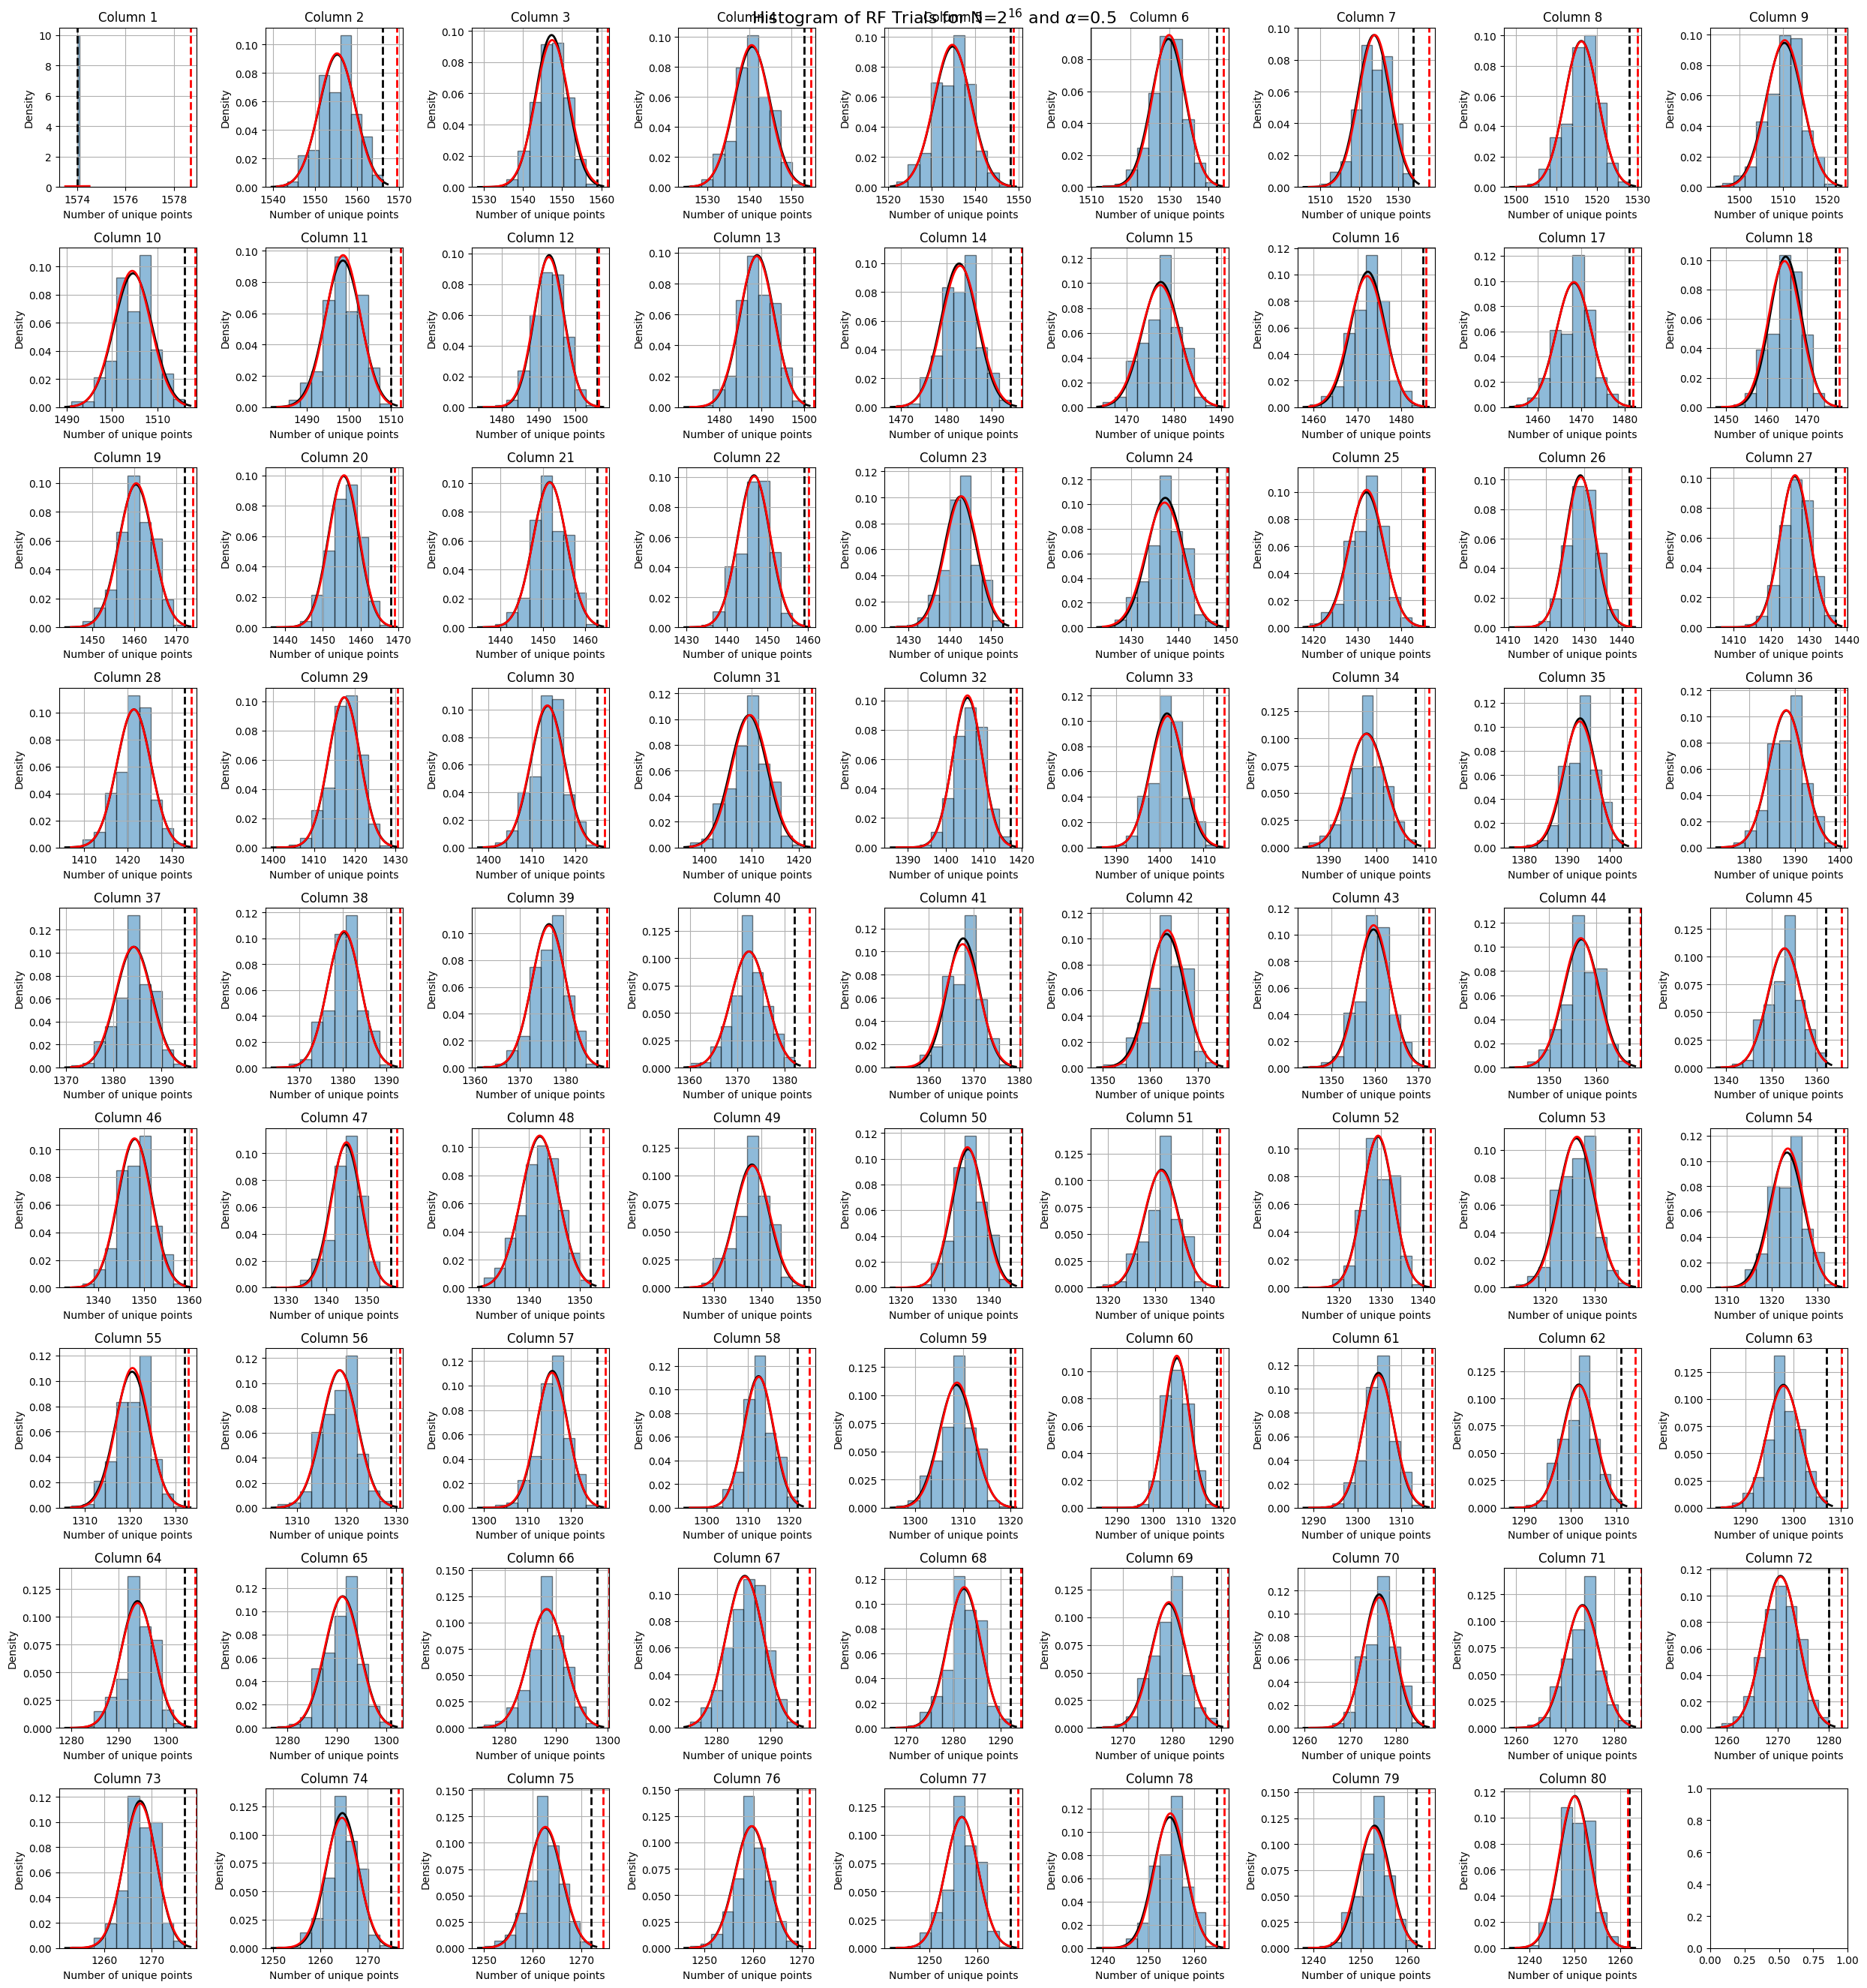

In [18]:
# get the rf results for alpha = 0.5
with open("trials_data/cherry_N_16_alpha_0.5_rf_results.pkl", "rb") as f:
    data = pickle.load(f)

sample_1 = []
for i in range(t):
    sample_1.append(data[0][i][1])

################################################################################################

# get the data for sample 1 number of points per column
# for each column, get the mean and varaince for the next column
means = []
variances = []

points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_0.5_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])

sample_1_points = points_df.iloc[0] # get the first sample (index 1)

# get mean and variance for each column based on sample_1_points
for i in range(t):
    mean, var = get_mean_variance(sample_1_points[i])
    means.append(mean)
    variances.append(var)

################################################################################################

# plot histogram of sample_1 for each column, 9 x 9 grid of subplots
fig, axes = plt.subplots(9, 9, figsize=(25, 27))
axes = axes.flatten()  # Flatten to a 1D array for easy indexing

for i in range(t):

    ax = axes[i]    

    # plot histogram of sample_1 for each column
    # ax.hist(sample_1[i], edgecolor='black')
    counts, bins, _ = ax.hist(sample_1[i], density=True, edgecolor='black', alpha=0.5) # Plot as density

    # plot this bell curve
    mu, std = norm.fit(sample_1[i])
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'k', linewidth=2)

    # plot what the actual column number was
    ax.axvline(x=sample_1_points[i+1], color='black', linestyle='dashed', linewidth=2, label='Actual Next Column')

    # plot a normal distribution curve for what the approximation would be
    x = np.linspace(min(bins), max(bins), 100)
    y = norm.pdf(x, means[i], sqrt(variances[i])) 
    ax.plot(x, y, color='red', lw=2)

    # plot what the approximation would give us as the next column
    approx = get_approximate_mi(means[i], len(sample_1[i]), sqrt(variances[i]))
    ax.axvline(approx, color='red', linestyle='dashed', linewidth=2, label='Approximation Mean')

    ax.set_xlabel("Number of unique points")
    ax.set_ylabel("Density")
    ax.ticklabel_format(useOffset=False, style='plain', axis='x')
    ax.set_title(f"Column {i+1}")
    ax.grid(True)

plt.suptitle(f"Histogram of RF Trials for N=$2^{{16}}$ and $\\alpha$=0.5", fontsize=16)
plt.tight_layout()  
plt.show()

In [19]:
# print a table for one sample
# Column | Max available points | Approximated M | Actual M 

print("Column | Max available points | Approximated M | Actual M | Approximate > Max?")
for i in range(t):
    approx = get_approximate_mi(means[i], len(sample_1[i]), sqrt(variances[i]))
    actual = sample_1_points[i+1]
    print(f"{i+1:6} | {sample_1_points[i]:20} | {approx:14.2f} | {actual:8} | {approx > sample_1_points[i]}")

Column | Max available points | Approximated M | Actual M | Approximate > Max?
     1 |                 1598 |        1578.69 |     1574 | False
     2 |                 1574 |        1569.42 |     1566 | False
     3 |                 1566 |        1561.55 |     1559 | False
     4 |                 1559 |        1554.66 |     1553 | False
     5 |                 1553 |        1548.75 |     1548 | False
     6 |                 1548 |        1543.83 |     1542 | False
     7 |                 1542 |        1537.92 |     1534 | False
     8 |                 1534 |        1530.05 |     1528 | False
     9 |                 1528 |        1524.14 |     1522 | False
    10 |                 1522 |        1518.23 |     1516 | False
    11 |                 1516 |        1512.32 |     1510 | False
    12 |                 1510 |        1506.41 |     1506 | False
    13 |                 1506 |        1502.47 |     1500 | False
    14 |                 1500 |        1496.56 |     1494 | Fal

C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\2318675426.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  actual = sample_1_points[i+1]
C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\2318675426.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{i+1:6} | {sample_1_points[i]:20} | {approx:14.2f} | {actual:8} | {approx > sample_1_points[i]}")


### For alpha = 0.95 sample 1

C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\3319667373.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean, var = get_mean_variance(sample_1_points[i])
c:\Users\psymf9\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2065: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\3319667373.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.axvline(x=sample_1_points[i+1], color='black', linestyle='dashed', linewidth=2, label='Actual Next Column')


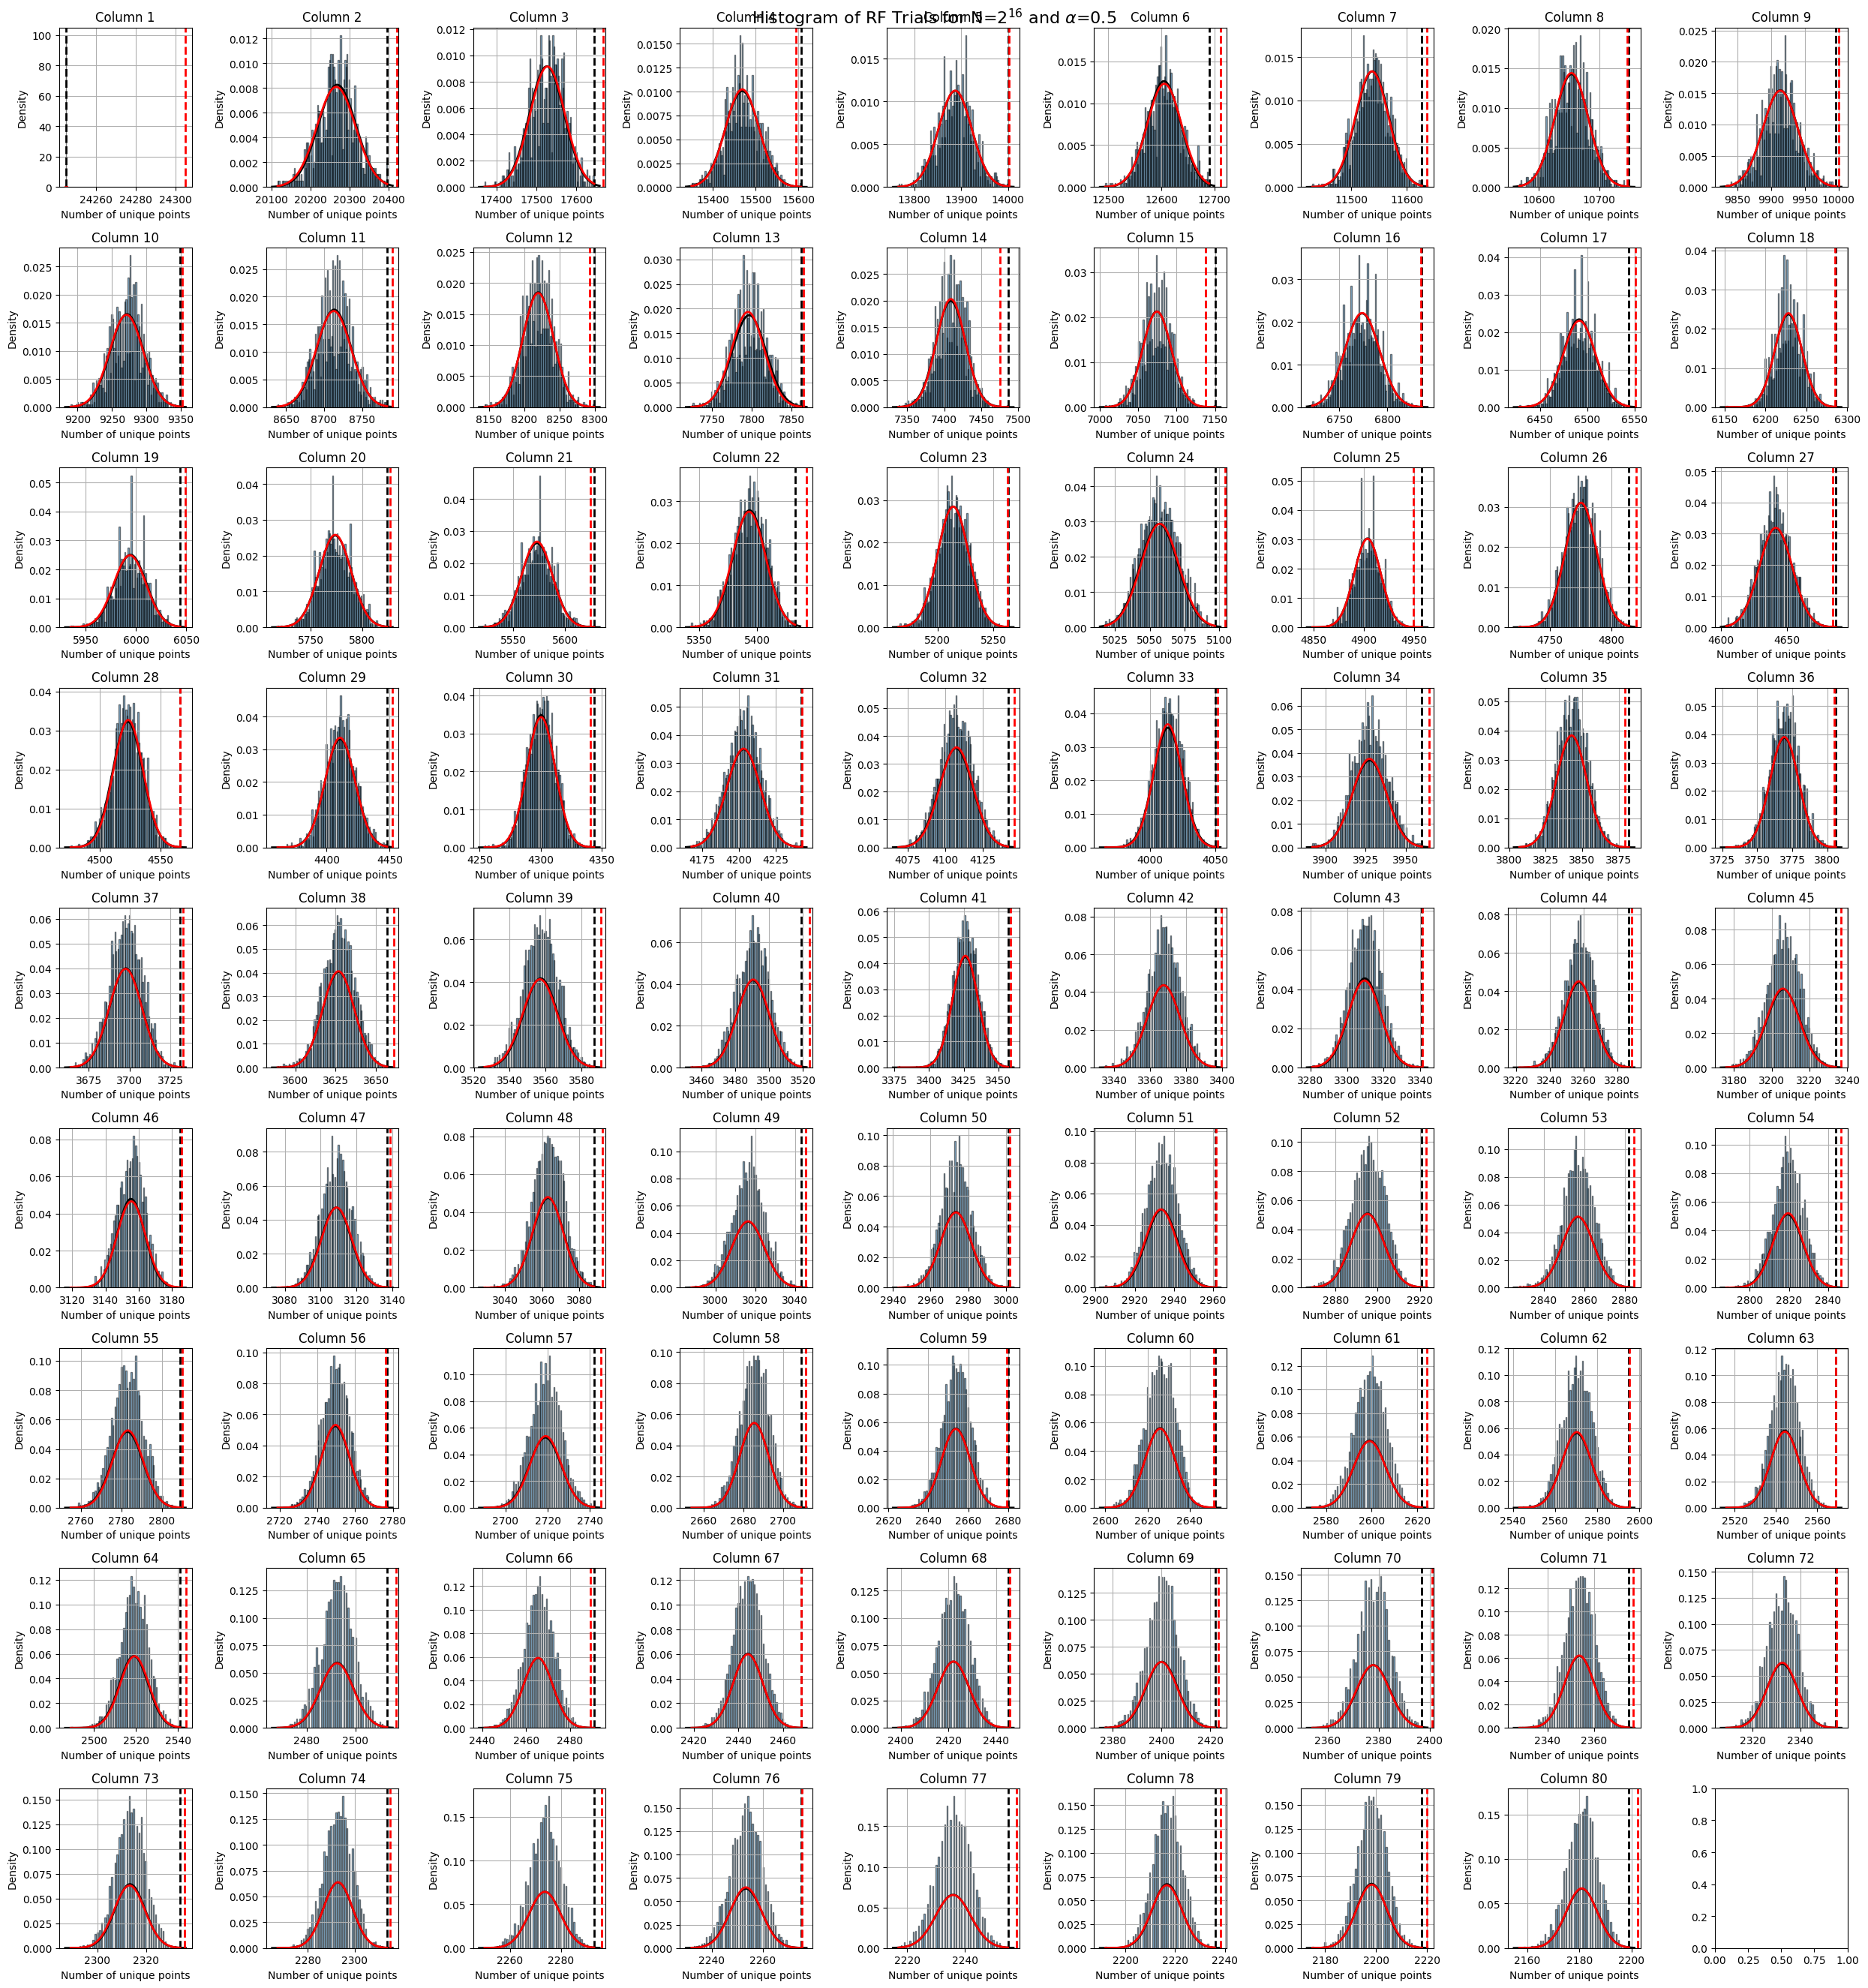

In [20]:
# get the rf results for alpha = 0.95
with open("trials_data/cherry_N_16_alpha_0.95_rf_results.pkl", "rb") as f:
    data = pickle.load(f)

sample_1 = []
for i in range(t):
    sample_1.append(data[0][i][1])

################################################################################################

# get the data for sample 1 number of points per column
# for each column, get the mean and varaince for the next column
means = []
variances = []

points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_0.95_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])

sample_1_points = points_df.iloc[0] # get the first sample (index 1)

# get mean and variance for each column based on sample_1_points
for i in range(t):
    mean, var = get_mean_variance(sample_1_points[i])
    means.append(mean)
    variances.append(var)

################################################################################################

# plot histogram of sample_1 for each column, 9 x 9 grid of subplots
fig, axes = plt.subplots(9, 9, figsize=(25, 27))
axes = axes.flatten()  # Flatten to a 1D array for easy indexing

for i in range(t):

    ax = axes[i]    

    # plot histogram of sample_1 for each column
    # ax.hist(sample_1[i], edgecolor='black')
    counts, bins, _ = ax.hist(sample_1[i], density=True, edgecolor='black', alpha=0.5, bins=100) # Plot as density

    # plot this bell curve
    mu, std = norm.fit(sample_1[i])
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'k', linewidth=2)

    # plot what the actual column number was
    ax.axvline(x=sample_1_points[i+1], color='black', linestyle='dashed', linewidth=2, label='Actual Next Column')

    # plot a normal distribution curve for what the approximation would be
    x = np.linspace(min(bins), max(bins), 100)
    y = norm.pdf(x, means[i], sqrt(variances[i])) 
    ax.plot(x, y, color='red', lw=2)

    # plot what the approximation would give us as the next column
    approx = get_approximate_mi(means[i], len(sample_1[i]), sqrt(variances[i]))
    ax.axvline(approx, color='red', linestyle='dashed', linewidth=2, label='Approximation Mean')

    ax.set_xlabel("Number of unique points")
    ax.set_ylabel("Density")
    ax.ticklabel_format(useOffset=False, style='plain', axis='x')
    ax.set_title(f"Column {i+1}")
    ax.grid(True)

plt.suptitle(f"Histogram of RF Trials for N=$2^{{16}}$ and $\\alpha$=0.5", fontsize=16)
plt.tight_layout()  
plt.show()

In [21]:
# print a table for one sample
# Column | Max available points | Approximated M | Actual M 

print("Column | Max available points | Approximated M | Actual M | Approximate > Max?")
for i in range(t):
    approx = get_approximate_mi(means[i], len(sample_1[i]), sqrt(variances[i]))
    actual = sample_1_points[i+1]
    print(f"{i+1:6} | {sample_1_points[i]:20} | {approx:14.2f} | {actual:8} | {approx > sample_1_points[i]}")

Column | Max available points | Approximated M | Actual M | Approximate > Max?
     1 |                30370 |       24305.15 |    24245 | False
     2 |                24245 |       20420.24 |    20396 | False
     3 |                20396 |       17665.81 |    17644 | False
     4 |                17644 |       15593.86 |    15606 | False
     5 |                15606 |       14001.87 |    14000 | False
     6 |                14000 |       12711.62 |    12690 | False
     7 |                12690 |       11635.27 |    11627 | False
     8 |                11627 |       10745.75 |    10749 | False
     9 |                10749 |        9999.98 |     9996 | False
    10 |                 9996 |        9352.27 |     9349 | False
    11 |                 9349 |        8789.72 |     8783 | False
    12 |                 8783 |        8292.95 |     8299 | False
    13 |                 8299 |        7864.71 |     7862 | False
    14 |                 7862 |        7475.30 |     7486 | Fal

C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\2318675426.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  actual = sample_1_points[i+1]
C:\Users\psymf9\AppData\Local\Temp\ipykernel_39192\2318675426.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{i+1:6} | {sample_1_points[i]:20} | {approx:14.2f} | {actual:8} | {approx > sample_1_points[i]}")


## Plot on multiple samples and see if it fits the normal distriibution

- get the data for all 20 samples
- plot all of these
- plot a normal distribution from all these points
- get the avg number of points for this column and mark on graph as black line
- get the avg points of last column and use that to build approximation and mark red line


### For alpha = 0.5

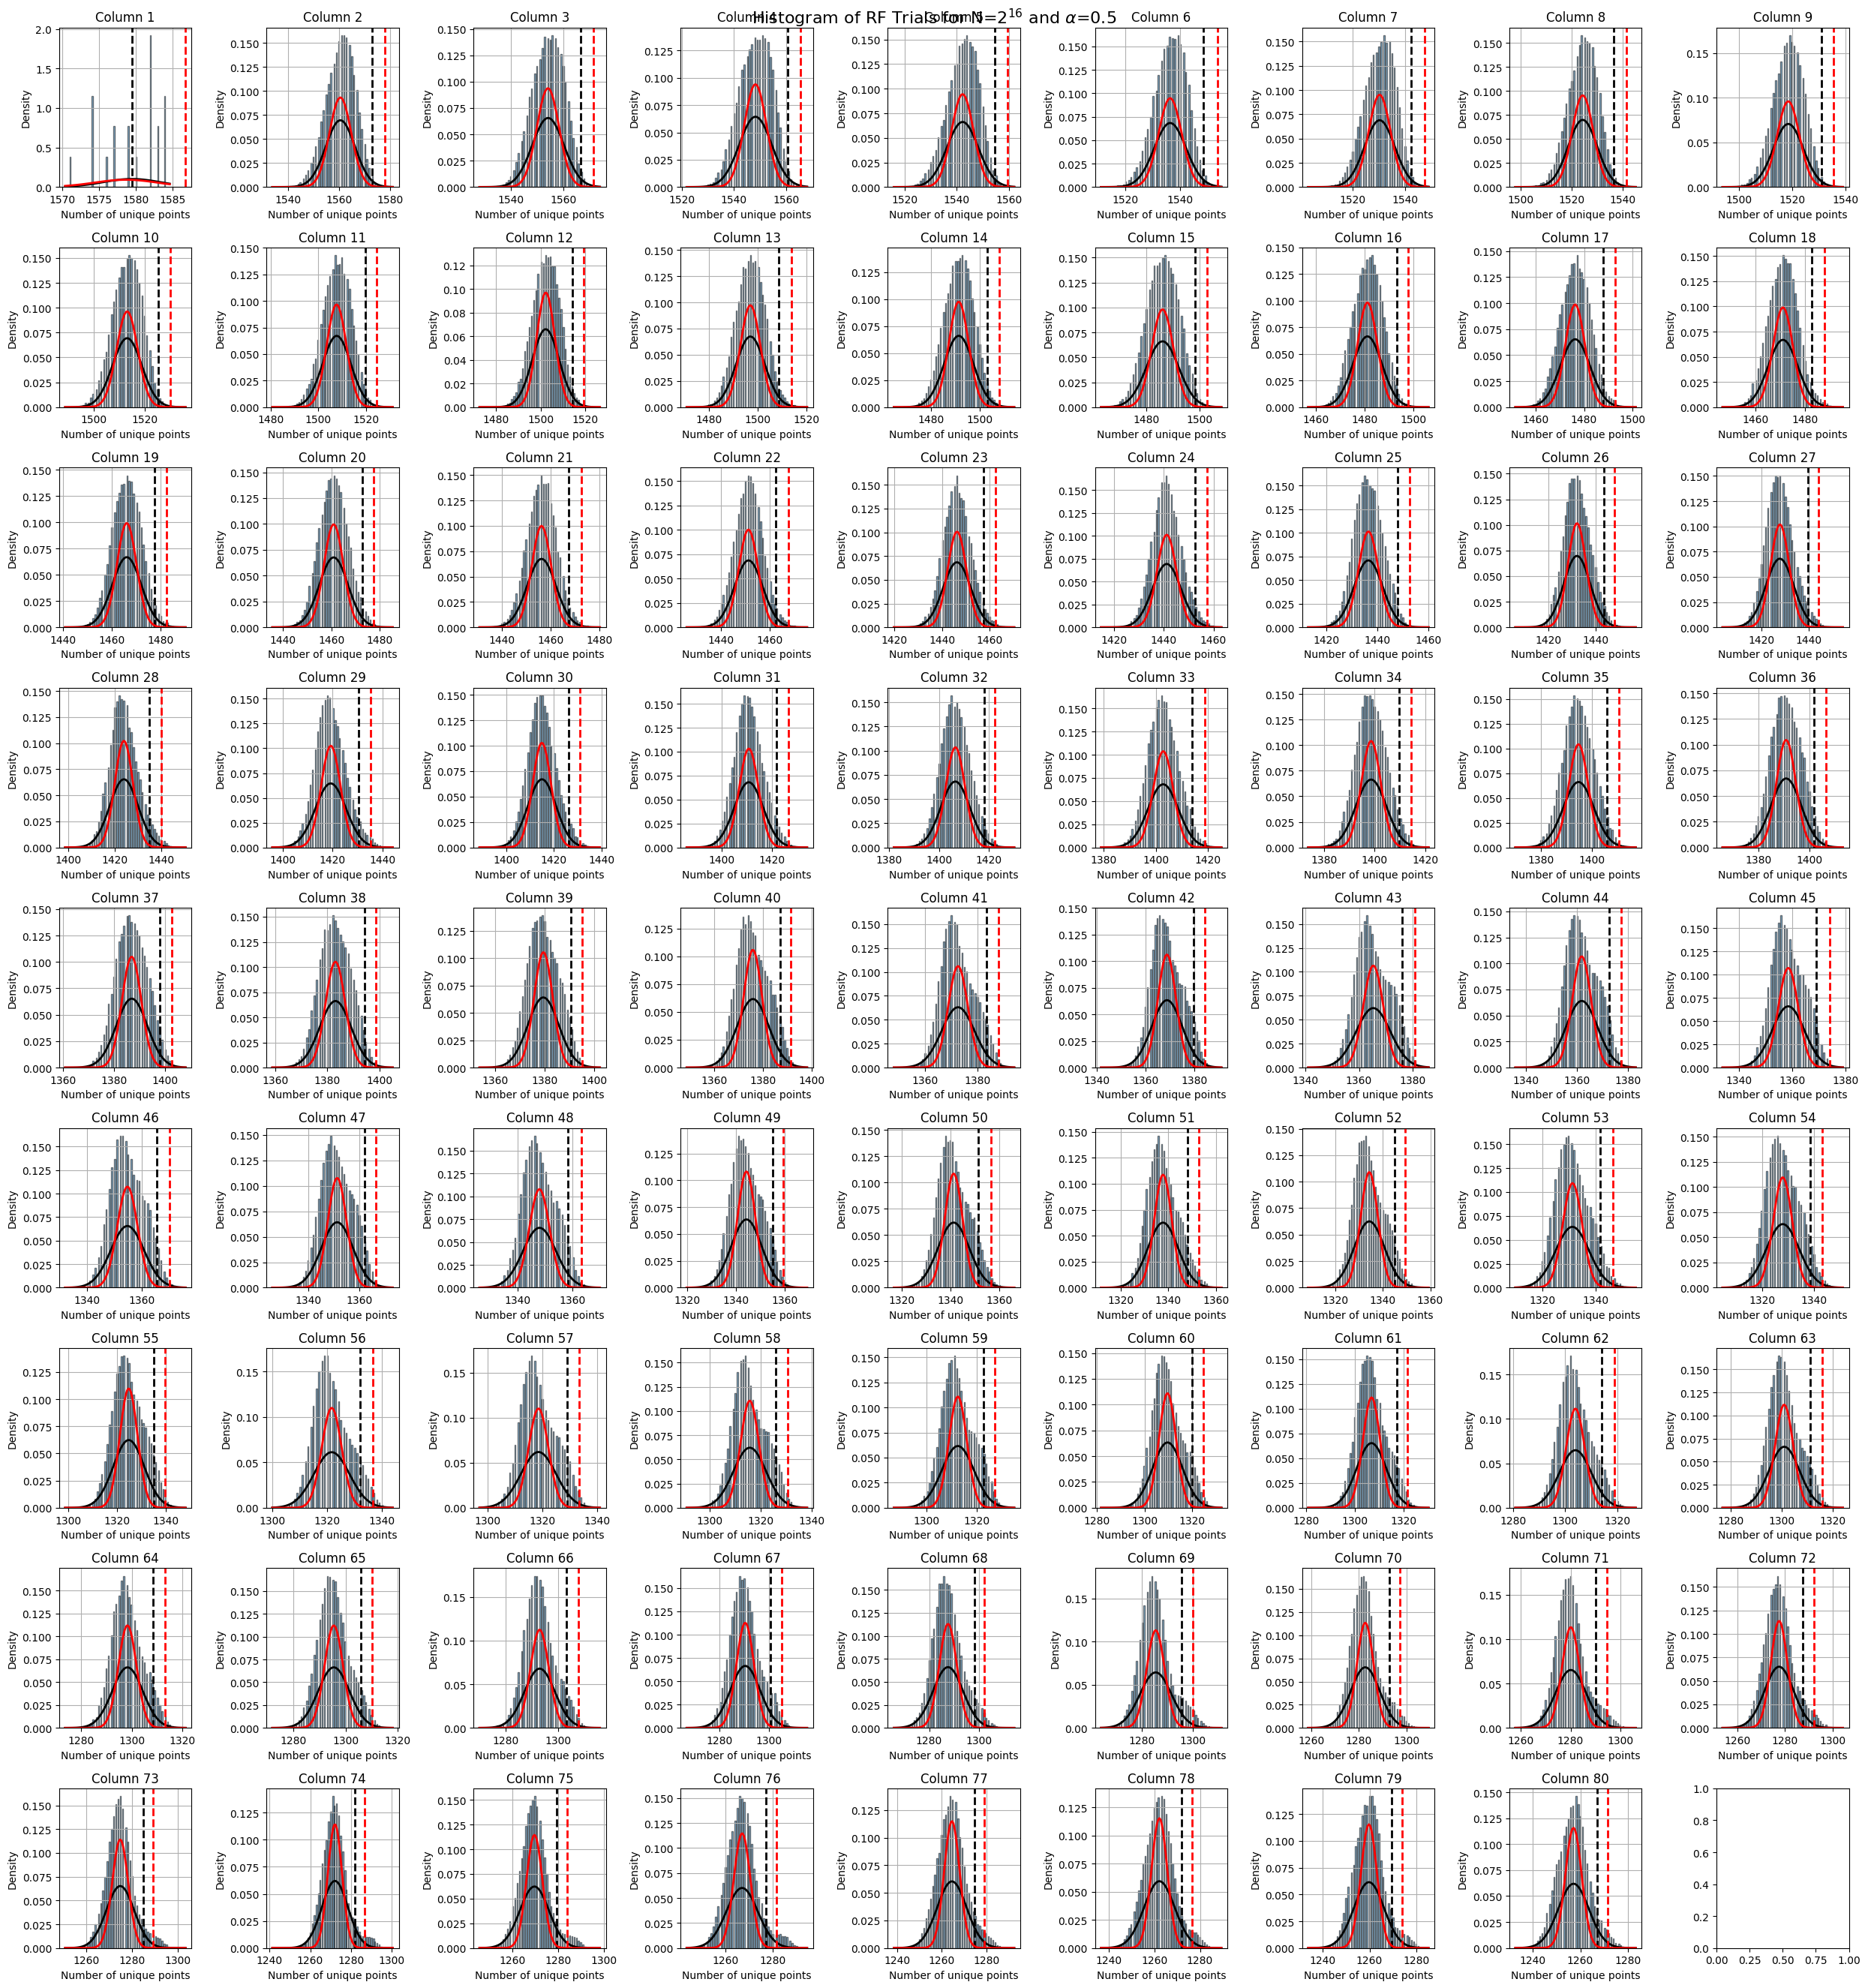

In [22]:
# get the rf results for alpha = 0.5
with open("trials_data/cherry_N_16_alpha_0.5_rf_results.pkl", "rb") as f:
    data = pickle.load(f)

# get num samples
num_samples = len(data)

sample_1_all = []

# list of t lists, each list contains the rf trials for that column
for i in range(t):
    column = []
    for j in range(num_samples):
        # just add to end of list, not as separate list
        column.extend(data[j][i][1])
    sample_1_all.append(column)

# # for all the samples
# for j in range(num_samples):
#     # for each sample, get the list of rf trials per column
#     sample_1 = []
#     for i in range(t):
#         sample_1.append(data[j][i][1])
#     # add to the whole sample
#     sample_1_all.append(sample_1)

################################################################################################

# get the data for sample 1 number of points per column
# for each column, get the mean and varaince for the next column
means = []
variances = []

points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_0.5_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])

# get the mean number of points for each column
# sample_1_points = points_df.iloc[0] # get the first sample (index 1)
sample_1_points = points_df.mean().tolist()

# get mean and variance for each column based on sample_1_points
for i in range(t):
    mean, var = get_mean_variance(sample_1_points[i])
    means.append(mean)
    variances.append(var)

################################################################################################

# plot histogram of sample_1 for each column, 9 x 9 grid of subplots
fig, axes = plt.subplots(9, 9, figsize=(25, 27))
axes = axes.flatten()  # Flatten to a 1D array for easy indexing

for i in range(t):

    ax = axes[i]    

    # plot histogram of sample_1 for each column
    # ax.hist(sample_1[i], edgecolor='black')
    counts, bins, _ = ax.hist(sample_1_all[i], density=True, edgecolor='black', alpha=0.5, bins=100) # Plot as density

    # plot this bell curve
    mu, std = norm.fit(sample_1_all[i])
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'k', linewidth=2)

    # plot what the actual column number was
    ax.axvline(x=sample_1_points[i+1], color='black', linestyle='dashed', linewidth=2, label='Actual Next Column')

    # plot a normal distribution curve for what the approximation would be
    # x = np.linspace(min(bins), max(bins), 100)
    x = np.linspace(xmin, xmax, 100)
    y = norm.pdf(x, means[i], sqrt(variances[i])) 
    ax.plot(x, y, color='red', lw=2)

    # plot what the approximation would give us as the next column
    approx = get_approximate_mi(means[i], len(sample_1_all[i]), sqrt(variances[i]))
    ax.axvline(approx, color='red', linestyle='dashed', linewidth=2, label='Approximation Mean')

    ax.set_xlabel("Number of unique points")
    ax.set_ylabel("Density")
    ax.ticklabel_format(useOffset=False, style='plain', axis='x')
    ax.set_title(f"Column {i+1}")
    ax.grid(True)

plt.suptitle(f"Histogram of RF Trials for N=$2^{{16}}$ and $\\alpha$=0.5", fontsize=16)
plt.tight_layout()  
plt.show()

### For alpha = 0.95

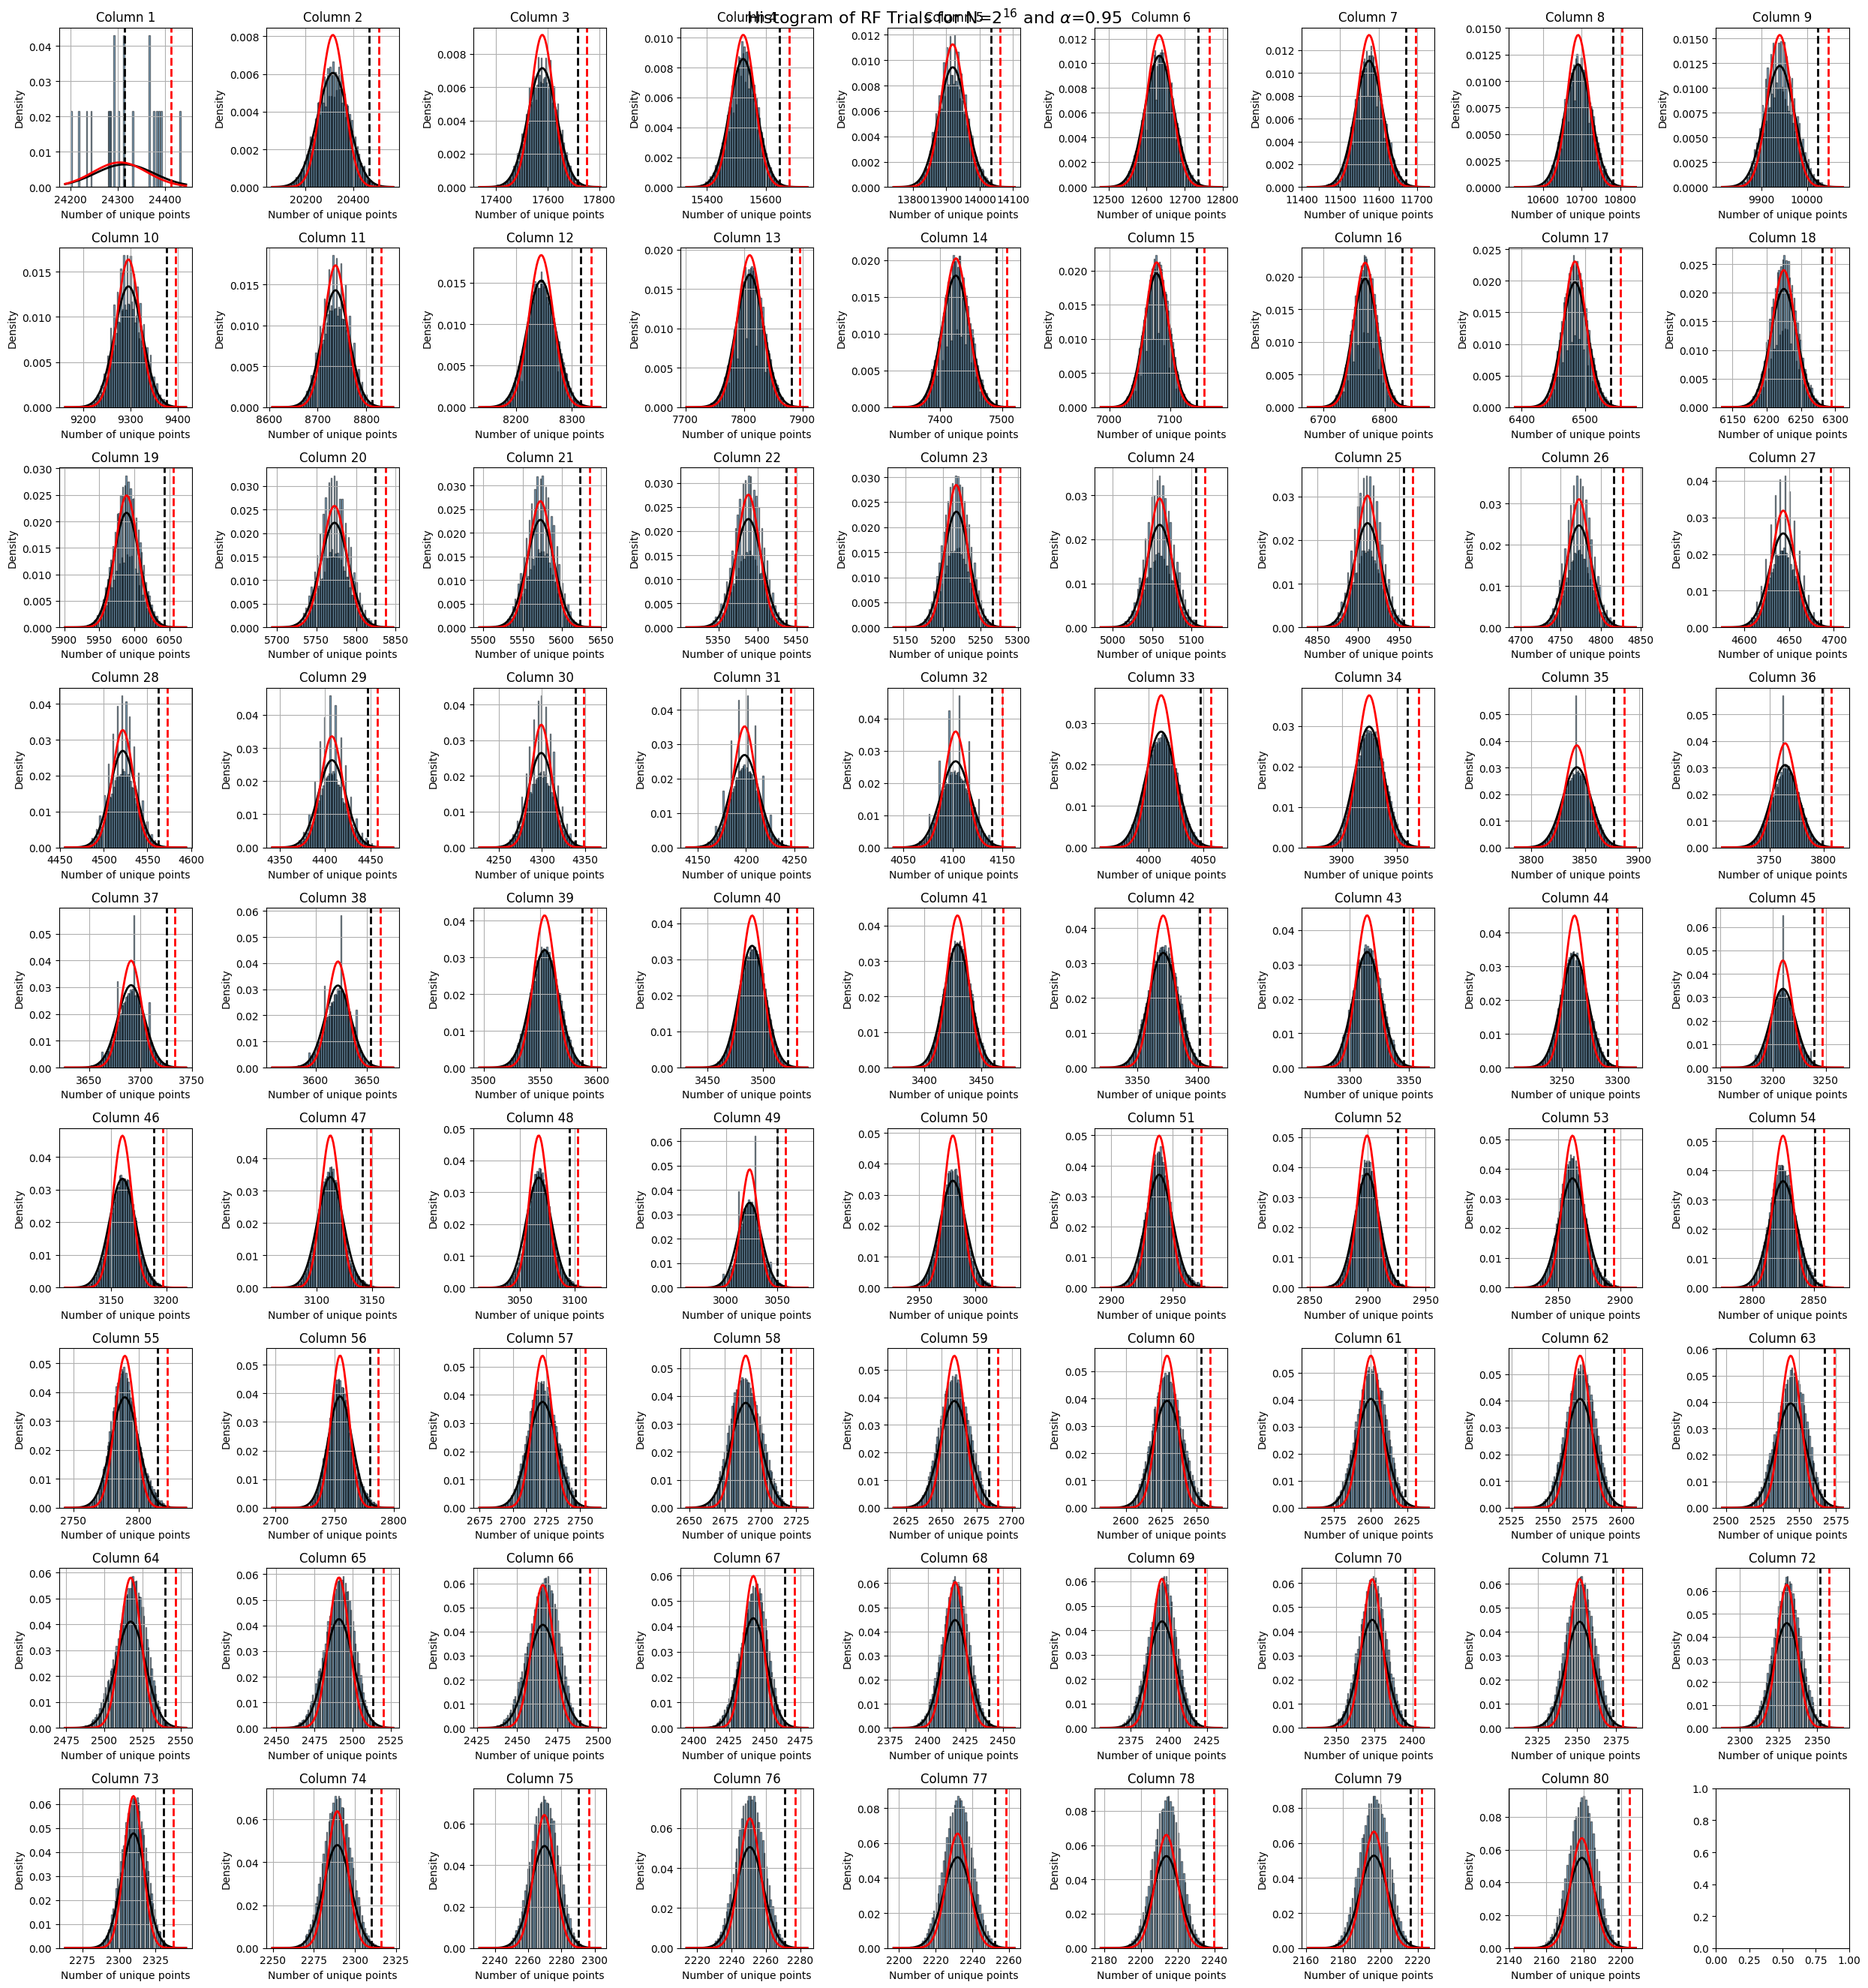

In [23]:
# get the rf results for alpha = 0.95
with open("trials_data/cherry_N_16_alpha_0.95_rf_results.pkl", "rb") as f:
    data = pickle.load(f)

# get num samples
num_samples = len(data)

sample_1_all = []

# list of t lists, each list contains the rf trials for that column
for i in range(t):
    column = []
    for j in range(num_samples):
        # just add to end of list, not as separate list
        column.extend(data[j][i][1])
    sample_1_all.append(column)

# # for all the samples
# for j in range(num_samples):
#     # for each sample, get the list of rf trials per column
#     sample_1 = []
#     for i in range(t):
#         sample_1.append(data[j][i][1])
#     # add to the whole sample
#     sample_1_all.append(sample_1)

################################################################################################

# get the data for sample 1 number of points per column
# for each column, get the mean and varaince for the next column
means = []
variances = []

points_all_df = pd.read_csv(f"trials_data/cherry_N_16_20_trials_alpha_0.95_points_per_column.csv")
points_df = points_all_df.drop(columns=["Trial"])

# get the mean number of points for each column
# sample_1_points = points_df.iloc[0] # get the first sample (index 1)
sample_1_points = points_df.mean().tolist()

# get mean and variance for each column based on sample_1_points
for i in range(t):
    mean, var = get_mean_variance(sample_1_points[i])
    means.append(mean)
    variances.append(var)

################################################################################################

# plot histogram of sample_1 for each column, 9 x 9 grid of subplots
fig, axes = plt.subplots(9, 9, figsize=(25, 27))
axes = axes.flatten()  # Flatten to a 1D array for easy indexing

for i in range(t):

    ax = axes[i]    

    # plot histogram of sample_1 for each column
    # ax.hist(sample_1[i], edgecolor='black')
    counts, bins, _ = ax.hist(sample_1_all[i], density=True, edgecolor='black', alpha=0.5, bins=100) # Plot as density

    # plot this bell curve
    mu, std = norm.fit(sample_1_all[i])
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'k', linewidth=2)

    # plot what the actual column number was
    ax.axvline(x=sample_1_points[i+1], color='black', linestyle='dashed', linewidth=2, label='Actual Next Column')

    # plot a normal distribution curve for what the approximation would be
    # x = np.linspace(min(bins), max(bins), 100)
    x = np.linspace(xmin, xmax, 100)
    y = norm.pdf(x, means[i], sqrt(variances[i])) 
    ax.plot(x, y, color='red', lw=2)

    # plot what the approximation would give us as the next column
    approx = get_approximate_mi(means[i], len(sample_1_all[i]), sqrt(variances[i]))
    ax.axvline(approx, color='red', linestyle='dashed', linewidth=2, label='Approximation Mean')

    ax.set_xlabel("Number of unique points")
    ax.set_ylabel("Density")
    ax.ticklabel_format(useOffset=False, style='plain', axis='x')
    ax.set_title(f"Column {i+1}")
    ax.grid(True)

plt.suptitle(f"Histogram of RF Trials for N=$2^{{16}}$ and $\\alpha$=0.95", fontsize=16)
plt.tight_layout()  
plt.show()